# **BARYONIFIED**

# SBI with cosmoGRID l1-norms

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Change "1" to the desired GPU index
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"  # Use 50% of GPU memory
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

from jaxili.inference import NPE

# device = jax.devices("gpu")[0] 
print("Device used by jax:", jax.devices())

# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform" # Avoids preallocation of GPU memory

Device used by jax: [CudaDevice(id=0)]


In [3]:
params = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_params_baryonified.npy', allow_pickle=True)

# **BIN 1**

In [3]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin1_baryonified_noisy_s026.npy', allow_pickle=True)

In [4]:
params.shape, l1_full.shape

((16966, 6), (16966, 5, 40))

## Scale 1

In [5]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16966, 40)

In [6]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [7]:
dataset = (params, l1_scale1)

In [8]:
inference = NPE()

In [9]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [10]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin1_scale1_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -6.214/ Best val loss -6.213:  10%|█         | 103/1000 [00:40<05:55,  2.52it/s]

Neural network training stopped after 104 epochs.
Early stopping with best validation metric: -6.213222026824951
Best model saved at epoch 93
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -6.570266246795654
[!] Validation loss: -6.214162349700928
[!] Test loss: -6.252370357513428


In [11]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [13]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_baryonified_fid_bin1_noisy_s026.npy', allow_pickle=True)

In [14]:
np.array(fid_full).shape

(200, 5, 40)

In [15]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [16]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [17]:
import jax.random as random

master_key = random.PRNGKey(1)

In [18]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [19]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [20]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


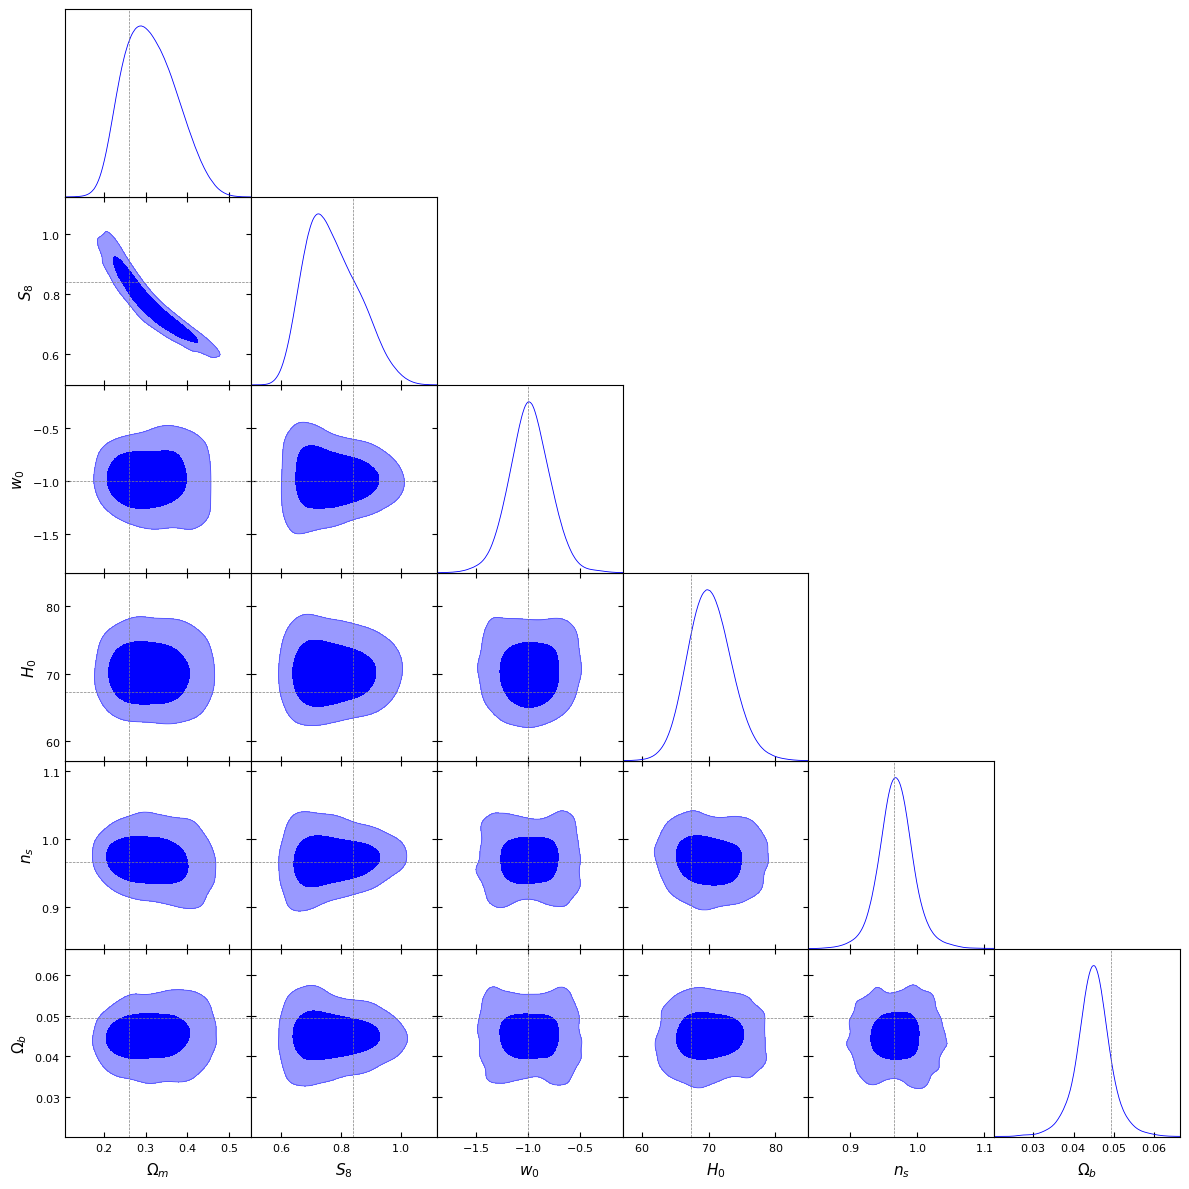

In [21]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_bar_bin1_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, scale1",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_bar_bin1_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [22]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_noisy_s026_npe.npy", samples_bar_bin1_scale1.samples)

## Scale 2

In [23]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16966, 40)

In [24]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)
dataset = (params, l1_scale2)

In [25]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [26]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin1_scale2_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.236/ Best val loss -7.244:  17%|█▋        | 169/1000 [00:56<04:37,  2.99it/s]

Neural network training stopped after 170 epochs.
Early stopping with best validation metric: -7.243838310241699
Best model saved at epoch 159
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.4009575843811035
[!] Validation loss: -7.244144439697266
[!] Test loss: -7.247236728668213


In [27]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [28]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [29]:
import jax.random as random

master_key = random.PRNGKey(1)

In [30]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [31]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [32]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


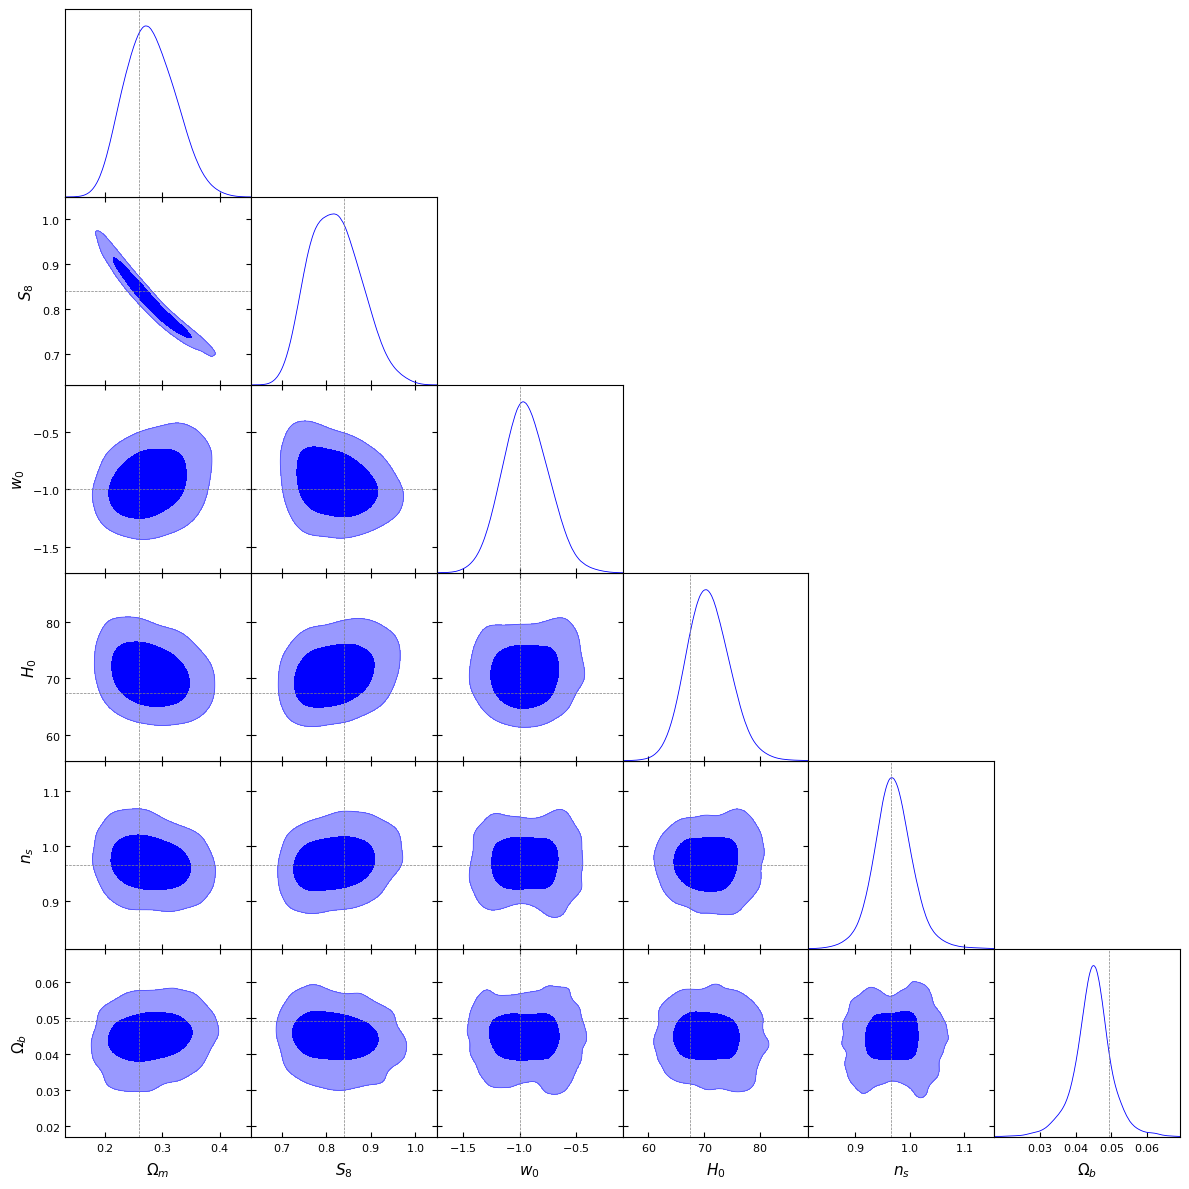

In [33]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_bar_bin1_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_bar_bin1_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [34]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin1_noisy_s026_npe.npy", samples_bar_bin1_scale2.samples)

## Scale 3

In [35]:
l1_scale3 = l1_full[:, 2]
l1_scale3.shape 

(16966, 40)

In [36]:
params = jnp.array(params)
l1_scale3 = jnp.array(l1_scale3)
dataset = (params, l1_scale3)

In [37]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [38]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin1_scale3_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -6.823/ Best val loss -6.833:  16%|█▌        | 158/1000 [00:58<05:09,  2.72it/s]

Neural network training stopped after 159 epochs.
Early stopping with best validation metric: -6.83344841003418
Best model saved at epoch 153
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -6.972125053405762
[!] Validation loss: -6.834272861480713
[!] Test loss: -6.8657002449035645


In [39]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [40]:
fid_mean_scale3 = fid_mean[2]
fid_mean_scale3.shape

(40,)

Sampling

In [41]:
import jax.random as random

master_key = random.PRNGKey(1)

In [42]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale3, num_samples=num_samples, key=sample_key
)

In [43]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [44]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


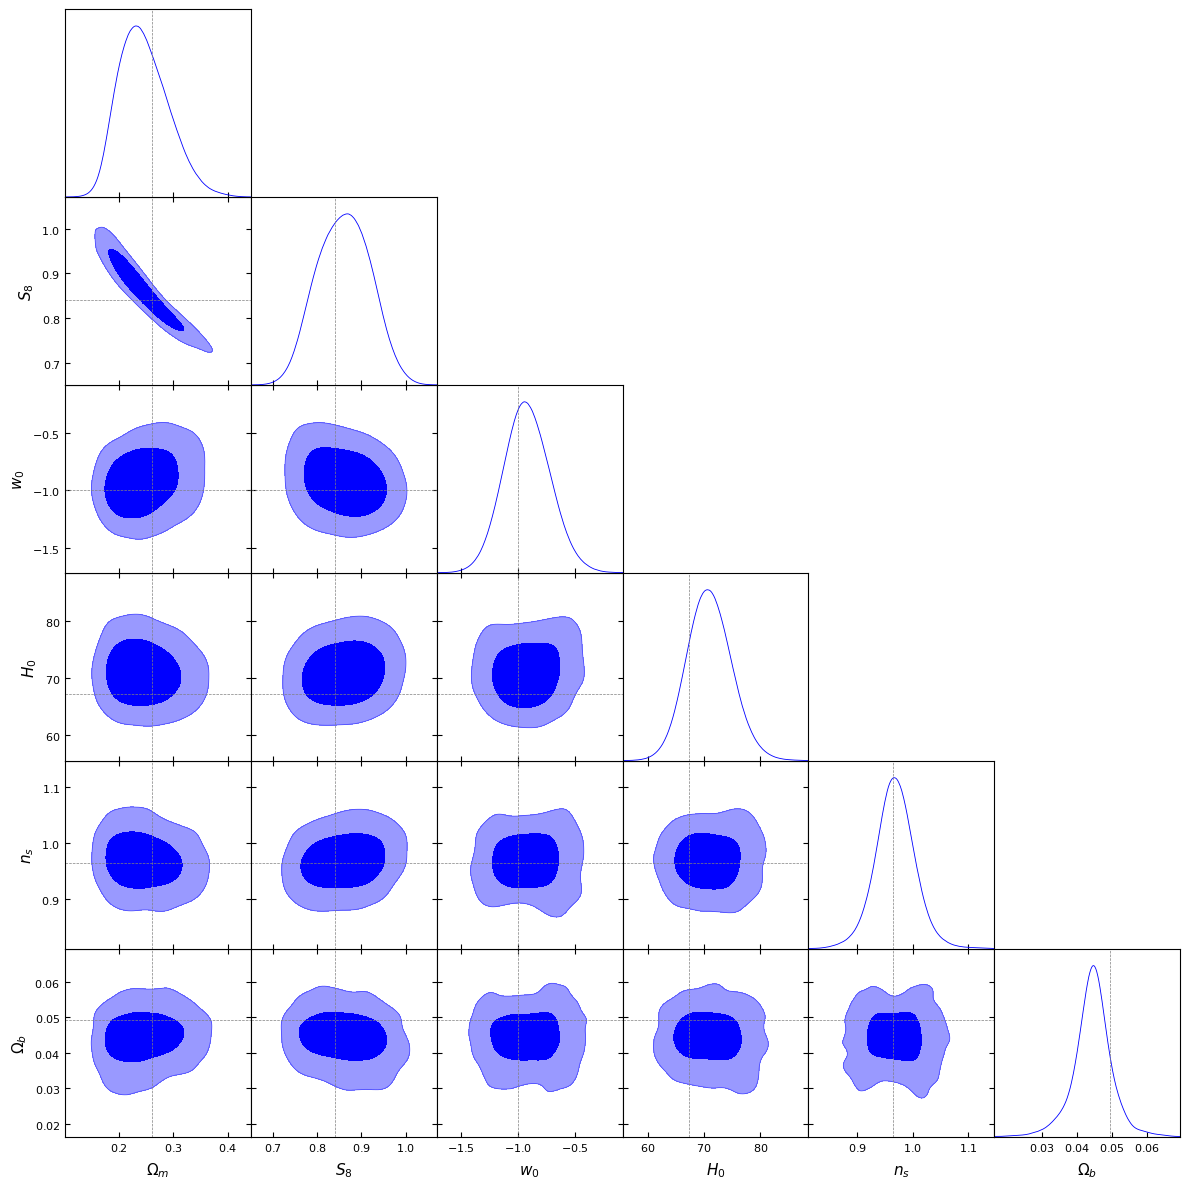

In [45]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_bar_bin1_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_bar_bin1_scale3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [46]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale3_bin1_noisy_s026_npe.npy", samples_bar_bin1_scale3.samples)

## Scale 4

In [47]:
l1_scale4 = l1_full[:, 3]
l1_scale4.shape 

(16966, 40)

In [48]:
params = jnp.array(params)
l1_scale4 = jnp.array(l1_scale4)
dataset = (params, l1_scale4)

In [49]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale4)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [50]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin1_scale4_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -6.004/ Best val loss -6.007:  14%|█▍        | 145/1000 [00:50<04:58,  2.86it/s]

Neural network training stopped after 146 epochs.
Early stopping with best validation metric: -6.006511688232422
Best model saved at epoch 128
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -6.169841766357422
[!] Validation loss: -6.006796836853027
[!] Test loss: -6.085702419281006


In [51]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [52]:
fid_mean_scale4 = fid_mean[3]
fid_mean_scale4.shape

(40,)

Sampling

In [53]:
import jax.random as random

master_key = random.PRNGKey(1)

In [54]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale4, num_samples=num_samples, key=sample_key
)

In [55]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [56]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


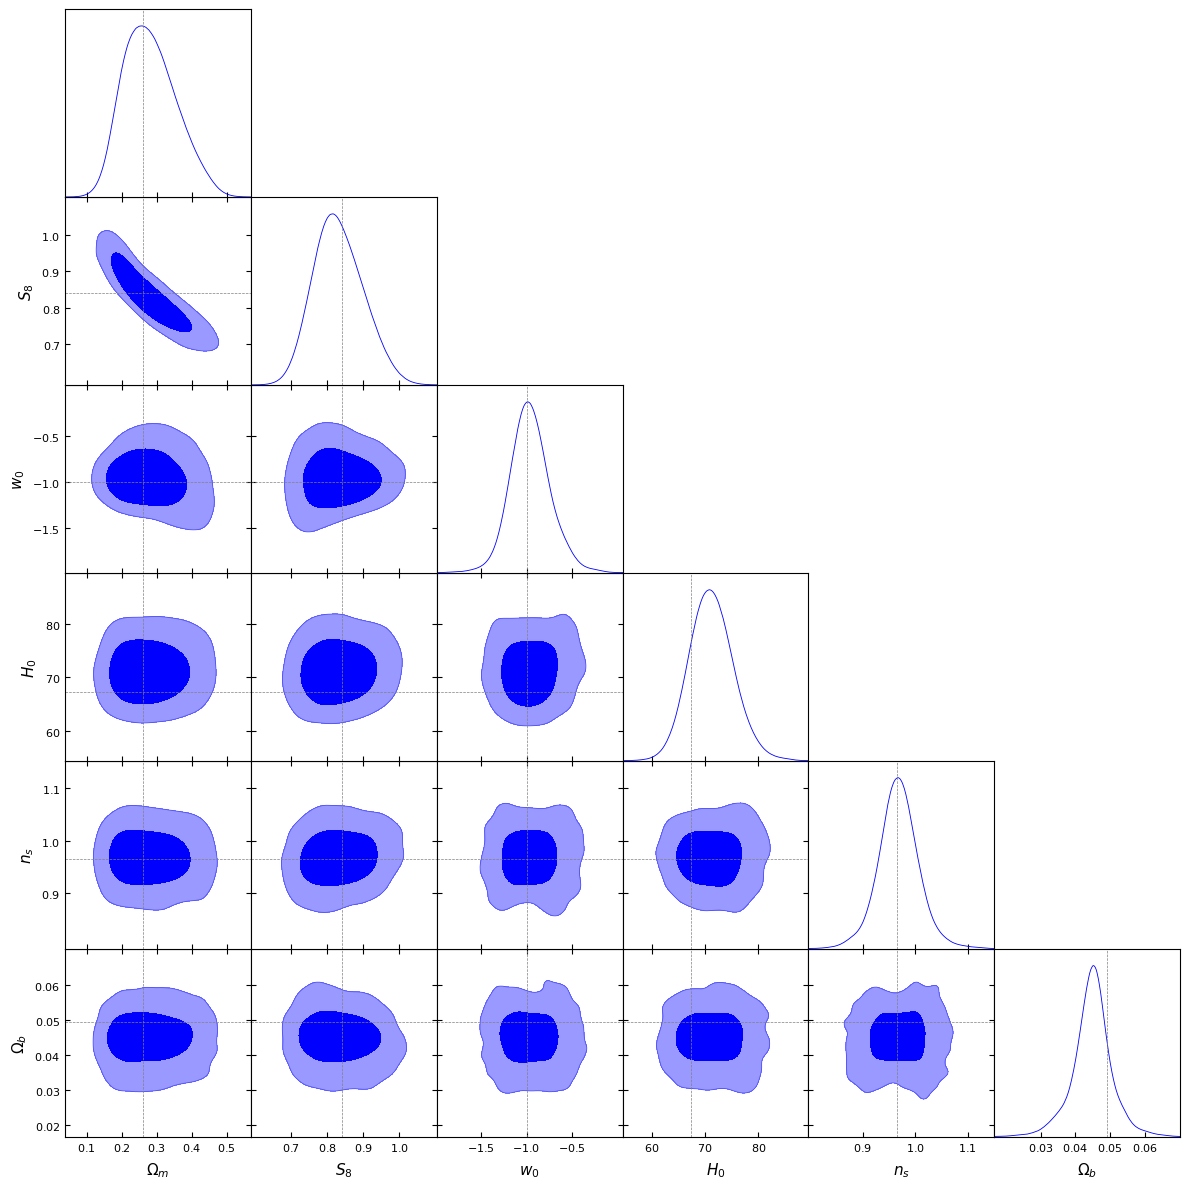

In [57]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_bar_bin1_scale4 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 4",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_bar_bin1_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [58]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale4_bin1_noisy_s026_npe.npy", samples_bar_bin1_scale4.samples)

## Scale 5

In [64]:
l1_scale5 = l1_full[:, 4]
l1_scale5.shape 

(16966, 40)

In [65]:
params = jnp.array(params)
l1_scale5 = jnp.array(l1_scale5)
dataset = (params, l1_scale5)

In [66]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale5)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [67]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_baryonified_bin1_scale5_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.


Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -5.056/ Best val loss -5.069:  10%|█         | 104/1000 [00:38<05:33,  2.68it/s]

Neural network training stopped after 105 epochs.
Early stopping with best validation metric: -5.068531513214111
Best model saved at epoch 100
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -5.298407077789307
[!] Validation loss: -5.069441318511963
[!] Test loss: -5.175205707550049


In [68]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [69]:
fid_mean_scale5 = fid_mean[4]
fid_mean_scale5.shape

(40,)

Sampling

In [70]:
import jax.random as random

master_key = random.PRNGKey(1)

In [71]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale5, num_samples=num_samples, key=sample_key
)

In [72]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [73]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


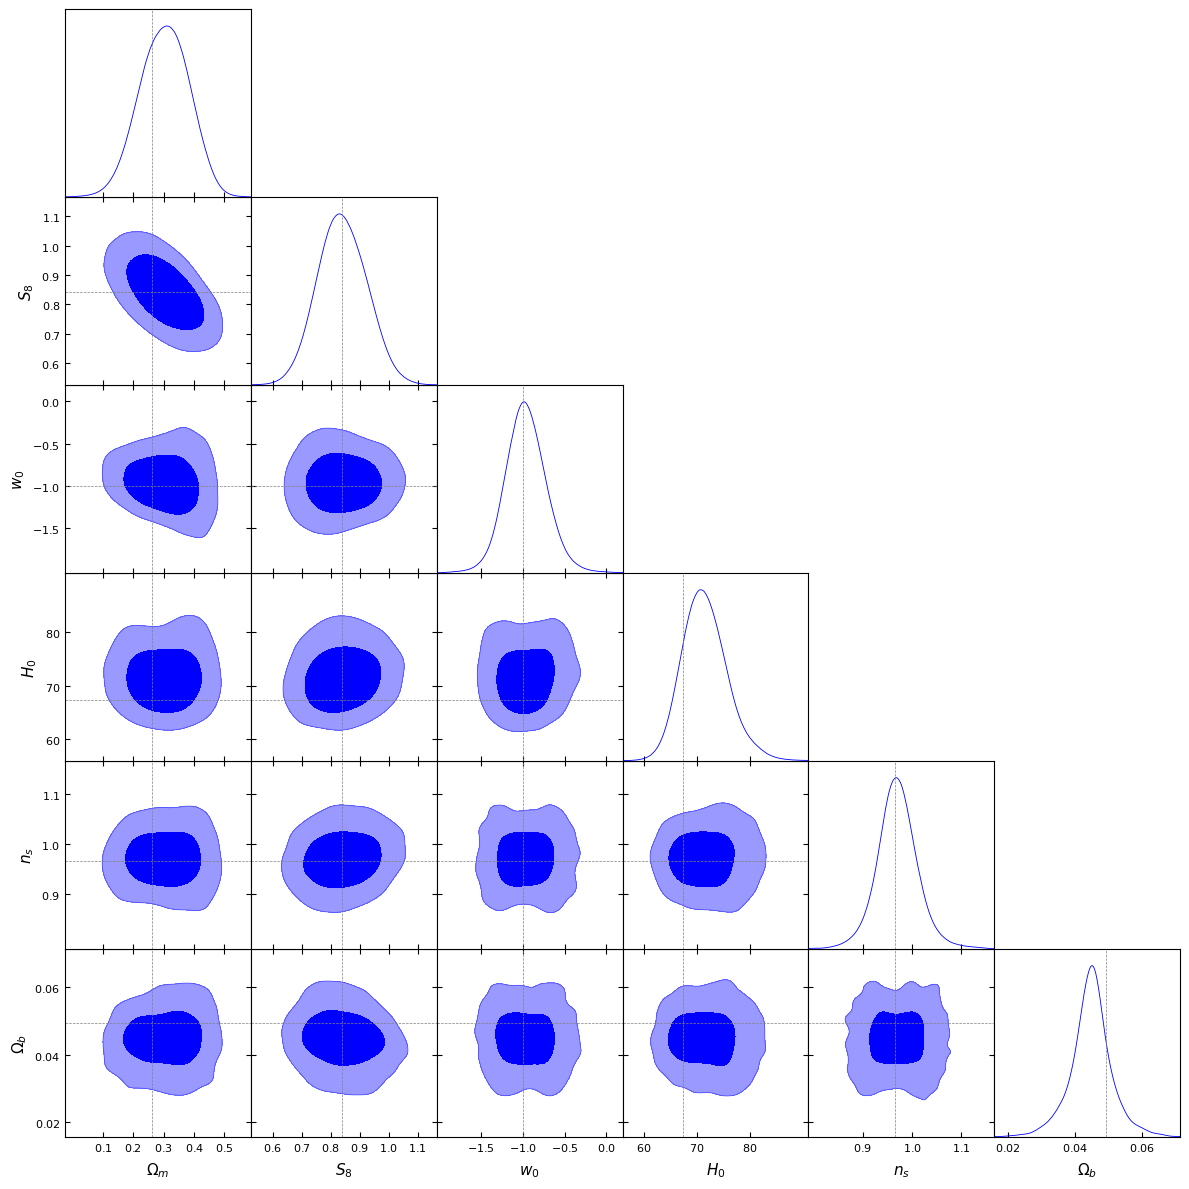

In [74]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_bar_bin1_scale5 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 5",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_bar_bin1_scale5], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [75]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale5_bin1_noisy_s026_npe.npy", samples_bar_bin1_scale5.samples)

### Compare scales

In [76]:
samples1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples3 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale3_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples4 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale4_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples5 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale5_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples = [samples1, samples2, samples3, samples4, samples5]

In [77]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]
samples_scale = []
for i in range(5):
    samples_scale_i = MCSamples(samples=samples[i], names=labels, label=f"Bar Noisy, bin1, scale{i+1}")
    samples_scale.append(samples_scale_i)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


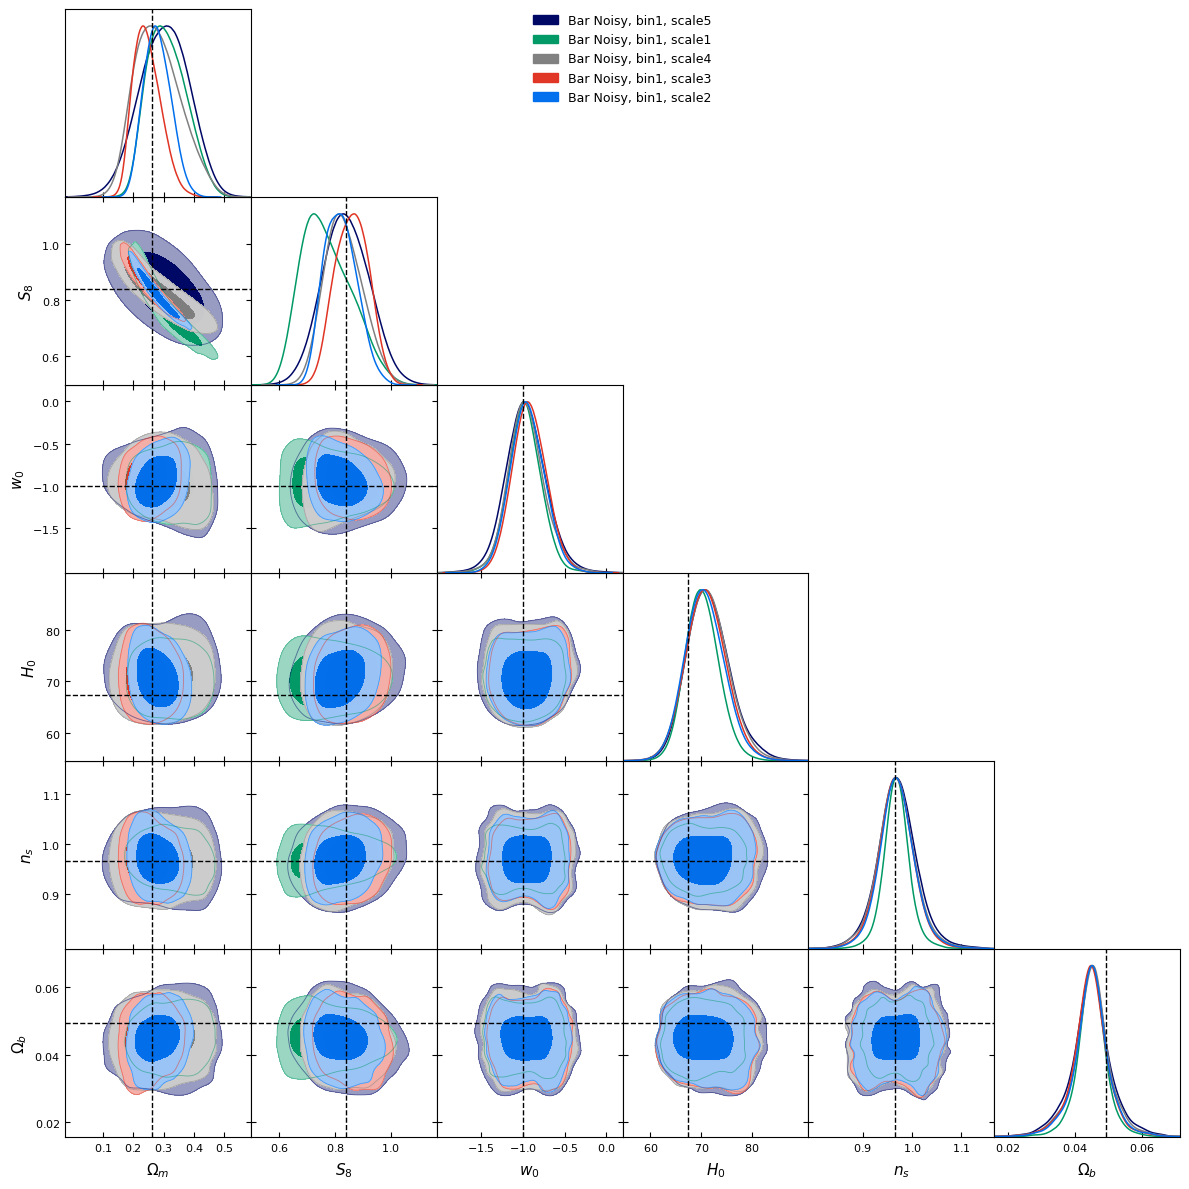

In [79]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ samples_scale[4], samples_scale[0], samples_scale[3], samples_scale[2], samples_scale[1]], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/posterior_triangle_plot_each_scale_bin1_noisy_s026_npe.pdf")
plt.show()

# Combine Scales

## 1+2

In [80]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
# combine the two scale histograms
l1_scales_1_2 = np.concatenate((l1_scale1, l1_scale2), axis=1)
l1_scales_1_2.shape 

(16966, 80)

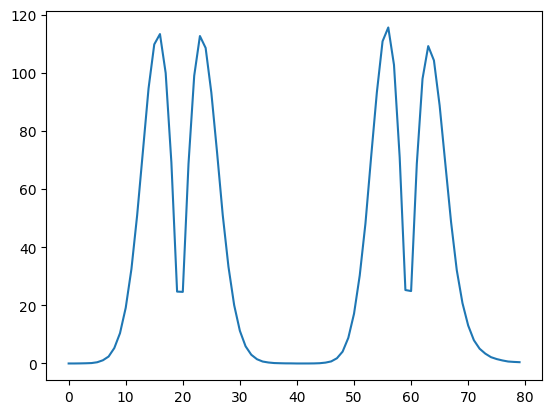

In [81]:
plt.plot(l1_scales_1_2[5])

In [82]:
params = jnp.array(params)
l1_scales_1_2 = jnp.array(l1_scales_1_2)
dataset = (params, l1_scales_1_2)

In [83]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [84]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1_2_bar_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.444/ Best val loss -7.483:  11%|█▏        | 113/1000 [00:43<05:38,  2.62it/s]

Neural network training stopped after 114 epochs.
Early stopping with best validation metric: -7.482516765594482
Best model saved at epoch 97
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.898442268371582
[!] Validation loss: -7.483160018920898
[!] Test loss: -7.457622051239014


In [85]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [86]:
fid_mean_scales_1_2 = np.concatenate((fid_mean[0], fid_mean[1]))
fid_mean_scales_1_2.shape

(80,)

Sampling

In [87]:
import jax.random as random

master_key = random.PRNGKey(1)

In [88]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2, num_samples=num_samples, key=sample_key
)

In [89]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [90]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


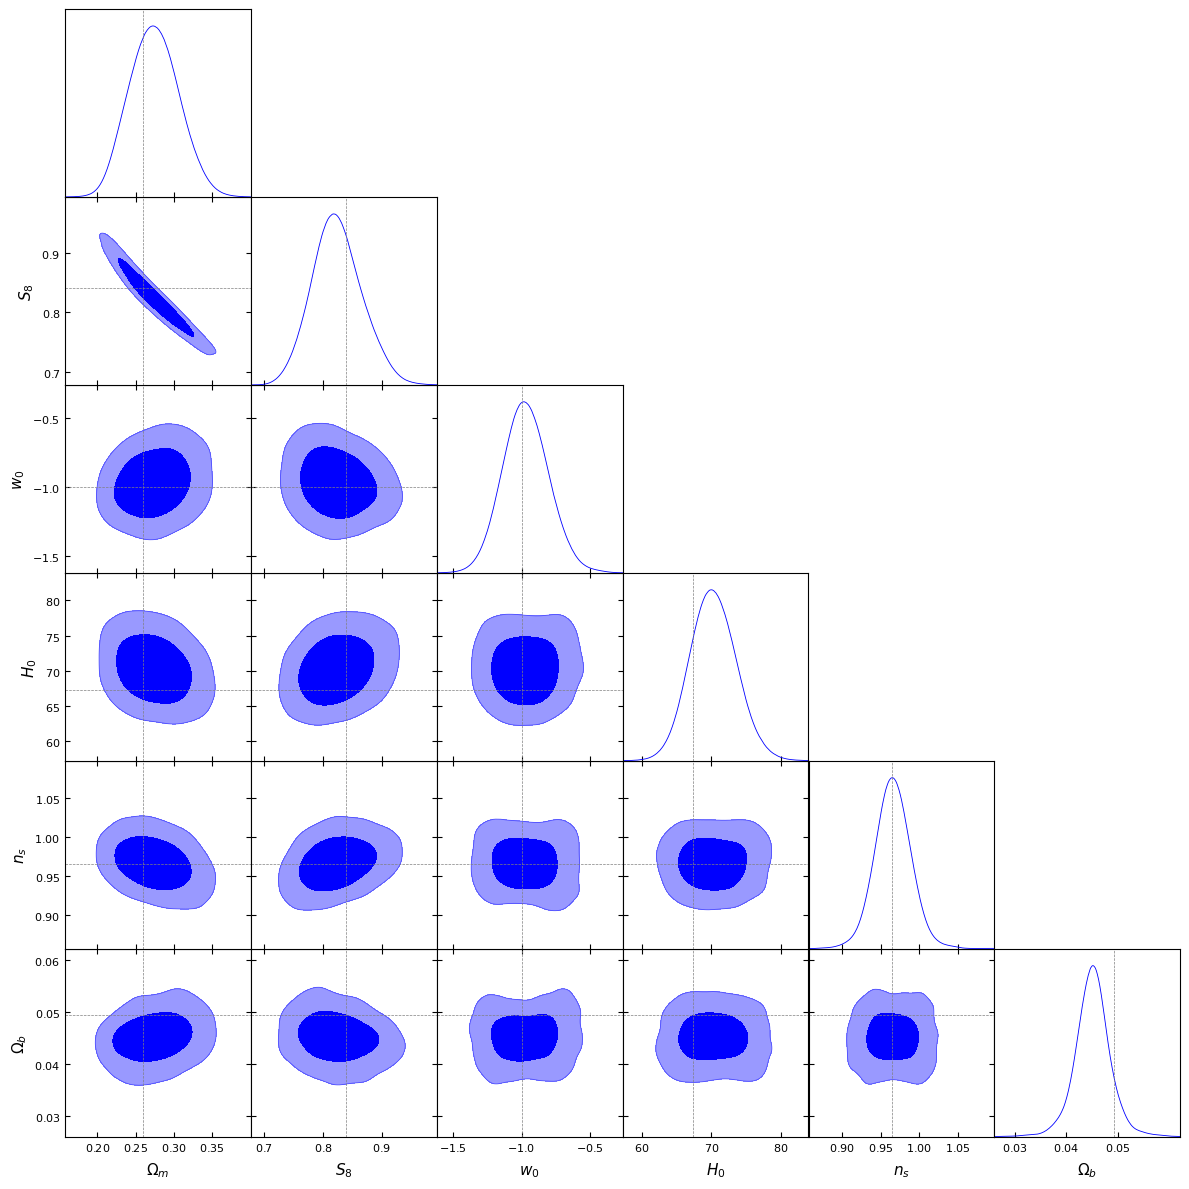

In [91]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2, Bin1, Bar, Noisy",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [92]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2_bin1_bar_noisy_s026_npe.npy", samples_gd_scales_1_2.samples)

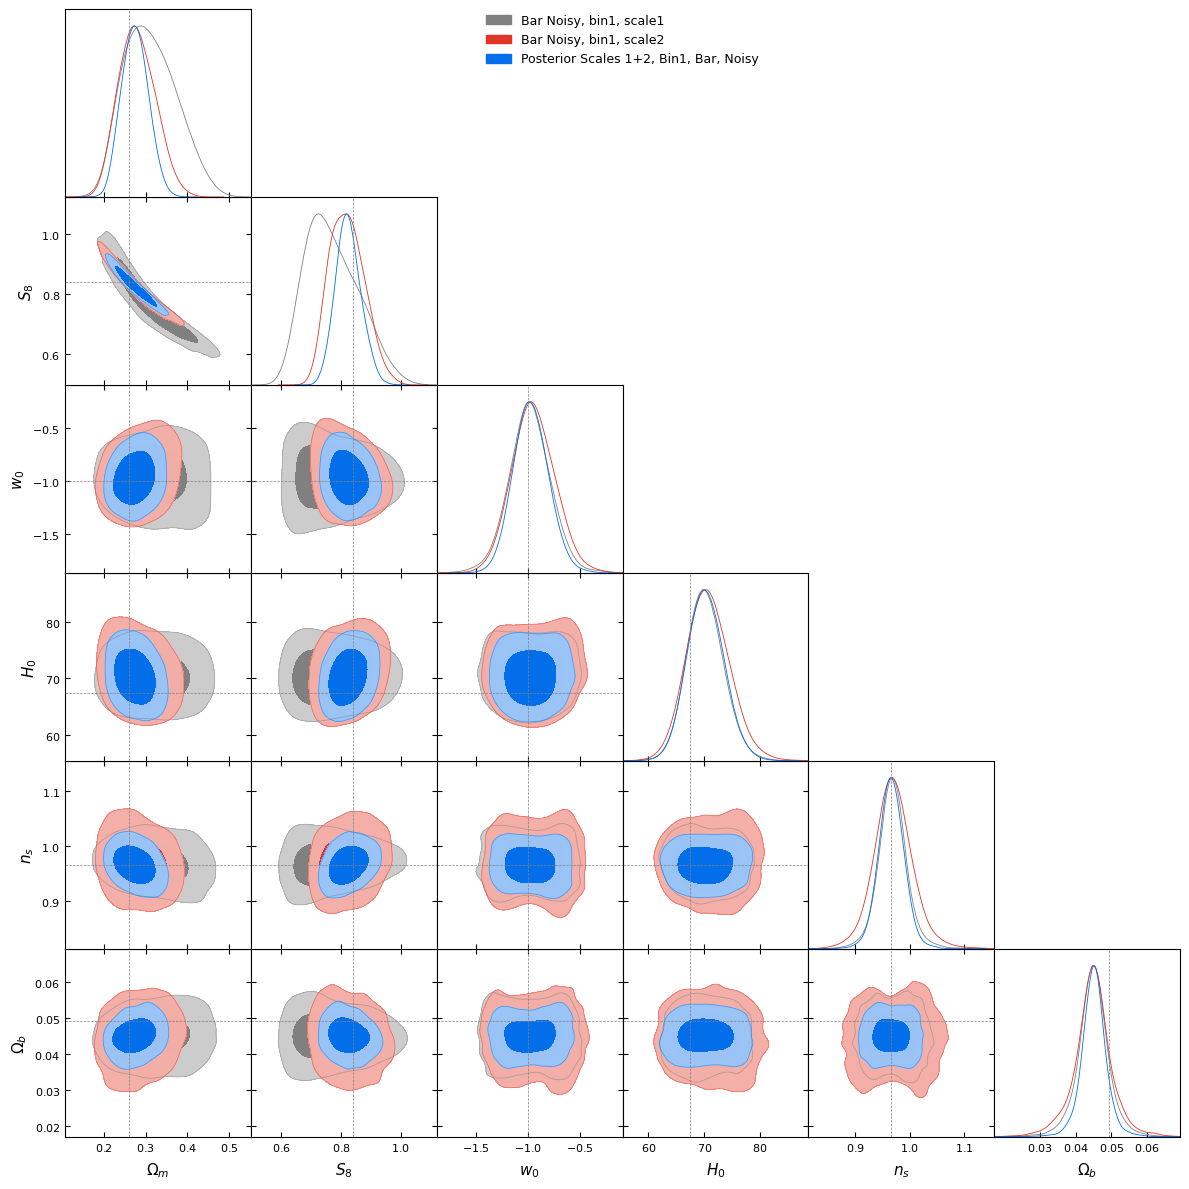

In [93]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale[0], samples_scale[1], samples_gd_scales_1_2], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## 1+2+3

In [94]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
l1_scale3 = l1_full[:, 2]
# combine the two scale histograms
l1_scales_1_2_3 = np.concatenate((l1_scale1, l1_scale2, l1_scale3), axis=1)
l1_scales_1_2_3.shape 

(16966, 120)

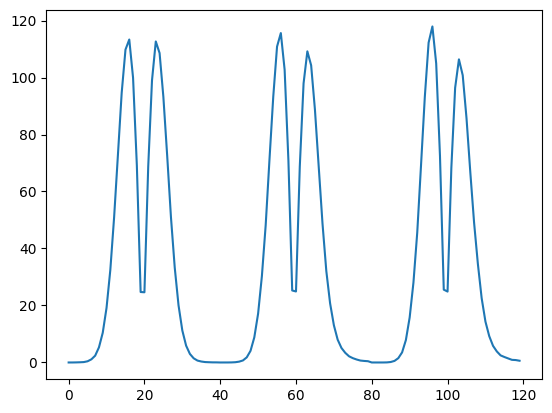

In [95]:
plt.plot(l1_scales_1_2_3[5])

In [96]:
params = jnp.array(params)
l1_scales_1_2_3 = jnp.array(l1_scales_1_2_3)
dataset = (params, l1_scales_1_2_3)

In [97]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2_3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [98]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1+2+3_bin1_bar_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.


[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -7.475/ Best val loss -7.532:  11%|█▏        | 113/1000 [00:40<05:19,  2.78it/s]

Neural network training stopped after 114 epochs.
Early stopping with best validation metric: -7.531981468200684
Best model saved at epoch 93
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.989062309265137
[!] Validation loss: -7.531981468200684
[!] Test loss: -7.442389011383057


In [99]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [100]:
fid_mean_scales_1_2_3 = np.concatenate((fid_mean[0], fid_mean[1], fid_mean[2]))
fid_mean_scales_1_2_3.shape

(120,)

Sampling

In [101]:
import jax.random as random

master_key = random.PRNGKey(1)

In [102]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2_3, num_samples=num_samples, key=sample_key
)

In [103]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [104]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


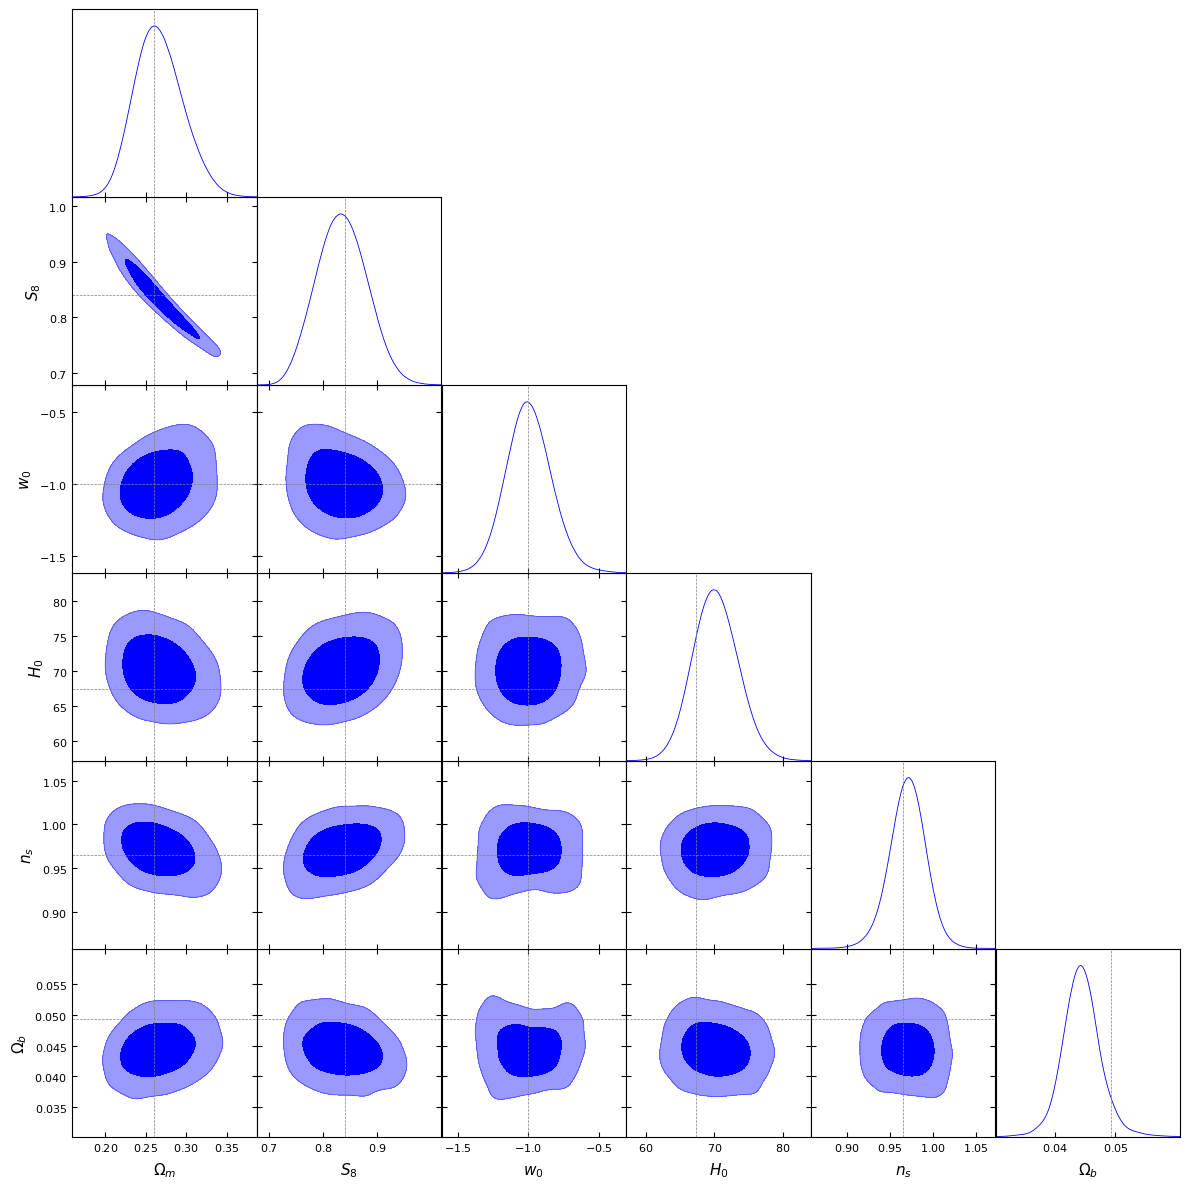

In [105]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2_3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2+3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2_3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [106]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+23_bin1_bar_noisy_s026_npe.npy", samples_gd_scales_1_2_3.samples)

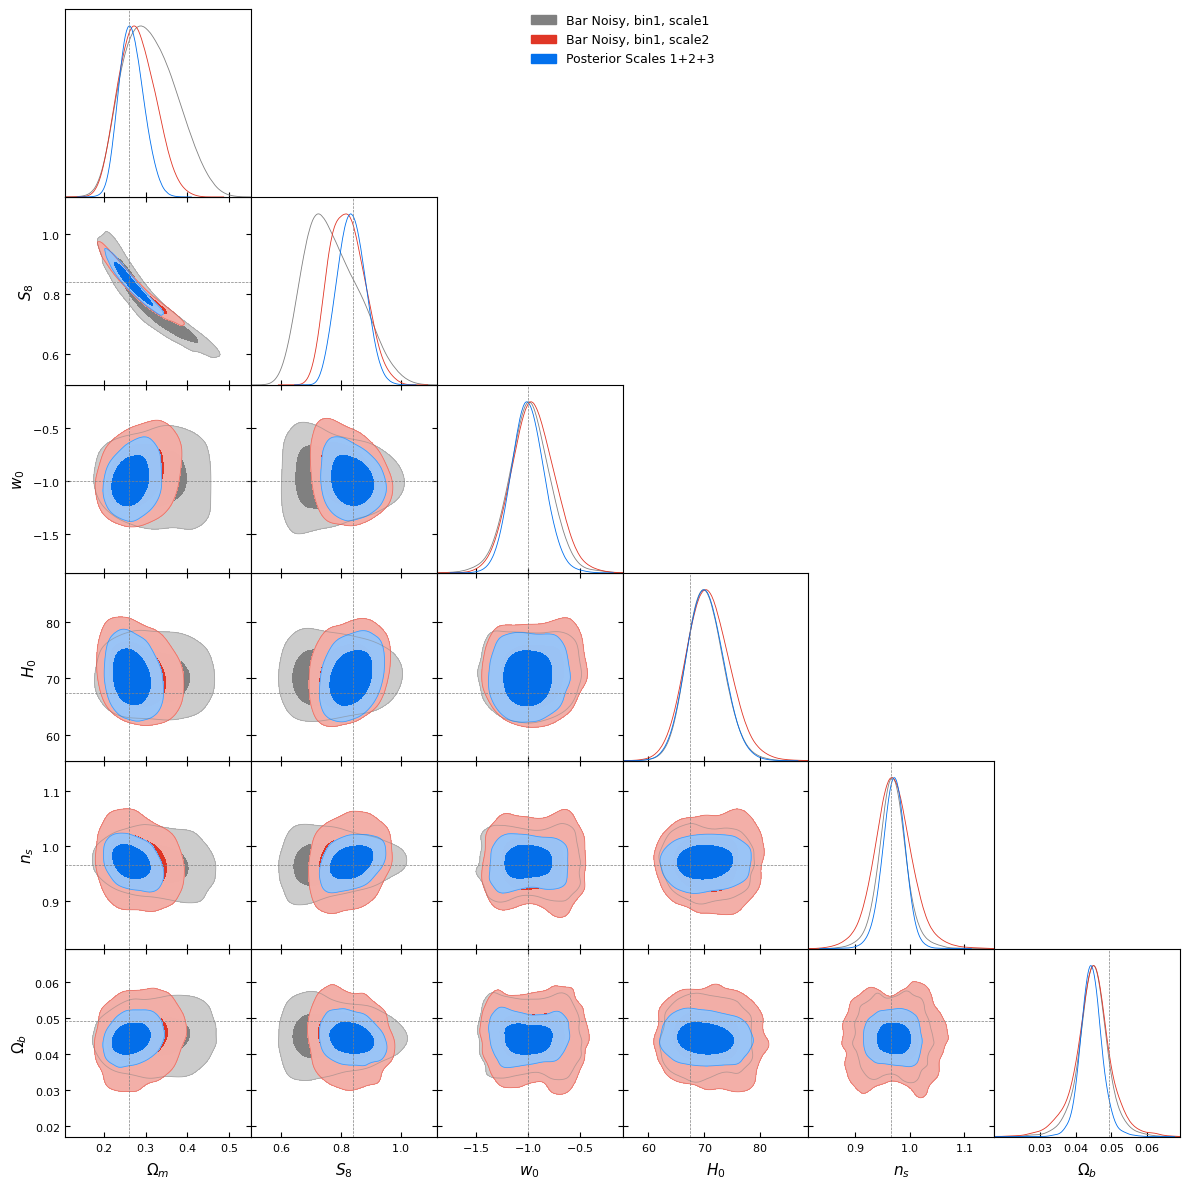

In [107]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale[0], samples_scale[1], samples_gd_scales_1_2_3], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## 1+2+3+4

In [108]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
l1_scale3 = l1_full[:, 2]
l1_scale4 = l1_full[:, 3]
# combine the two scale histograms
l1_scales_1_2_3_4 = np.concatenate((l1_scale1, l1_scale2, l1_scale3, l1_scale4), axis=1)
l1_scales_1_2_3_4.shape 

(16966, 160)

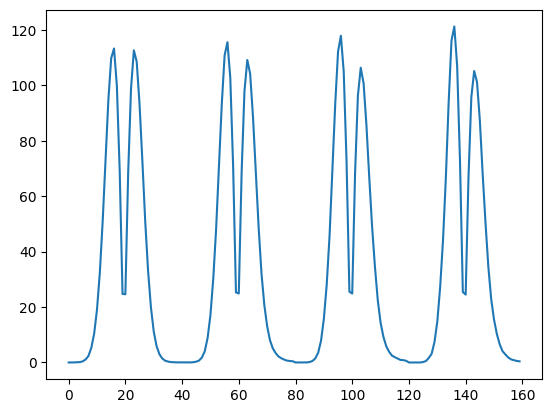

In [109]:
plt.plot(l1_scales_1_2_3_4[5])

In [110]:
params = jnp.array(params)
l1_scales_1_2_3_4 = jnp.array(l1_scales_1_2_3_4)
dataset = (params, l1_scales_1_2_3_4)

In [111]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2_3_4)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [112]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1+2+3+4_bin1_bar_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.475/ Best val loss -7.501:   9%|▉         | 88/1000 [00:35<06:11,  2.45it/s] 

Neural network training stopped after 89 epochs.
Early stopping with best validation metric: -7.501383304595947
Best model saved at epoch 68
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.890899181365967
[!] Validation loss: -7.501383304595947
[!] Test loss: -7.504975318908691


In [113]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [114]:
fid_mean_scales_1_2_3_4 = np.concatenate((fid_mean[0], fid_mean[1], fid_mean[2], fid_mean[3]))
fid_mean_scales_1_2_3_4.shape

(160,)

Sampling

In [115]:
import jax.random as random

master_key = random.PRNGKey(1)

In [116]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2_3_4, num_samples=num_samples, key=sample_key
)

In [117]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [118]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


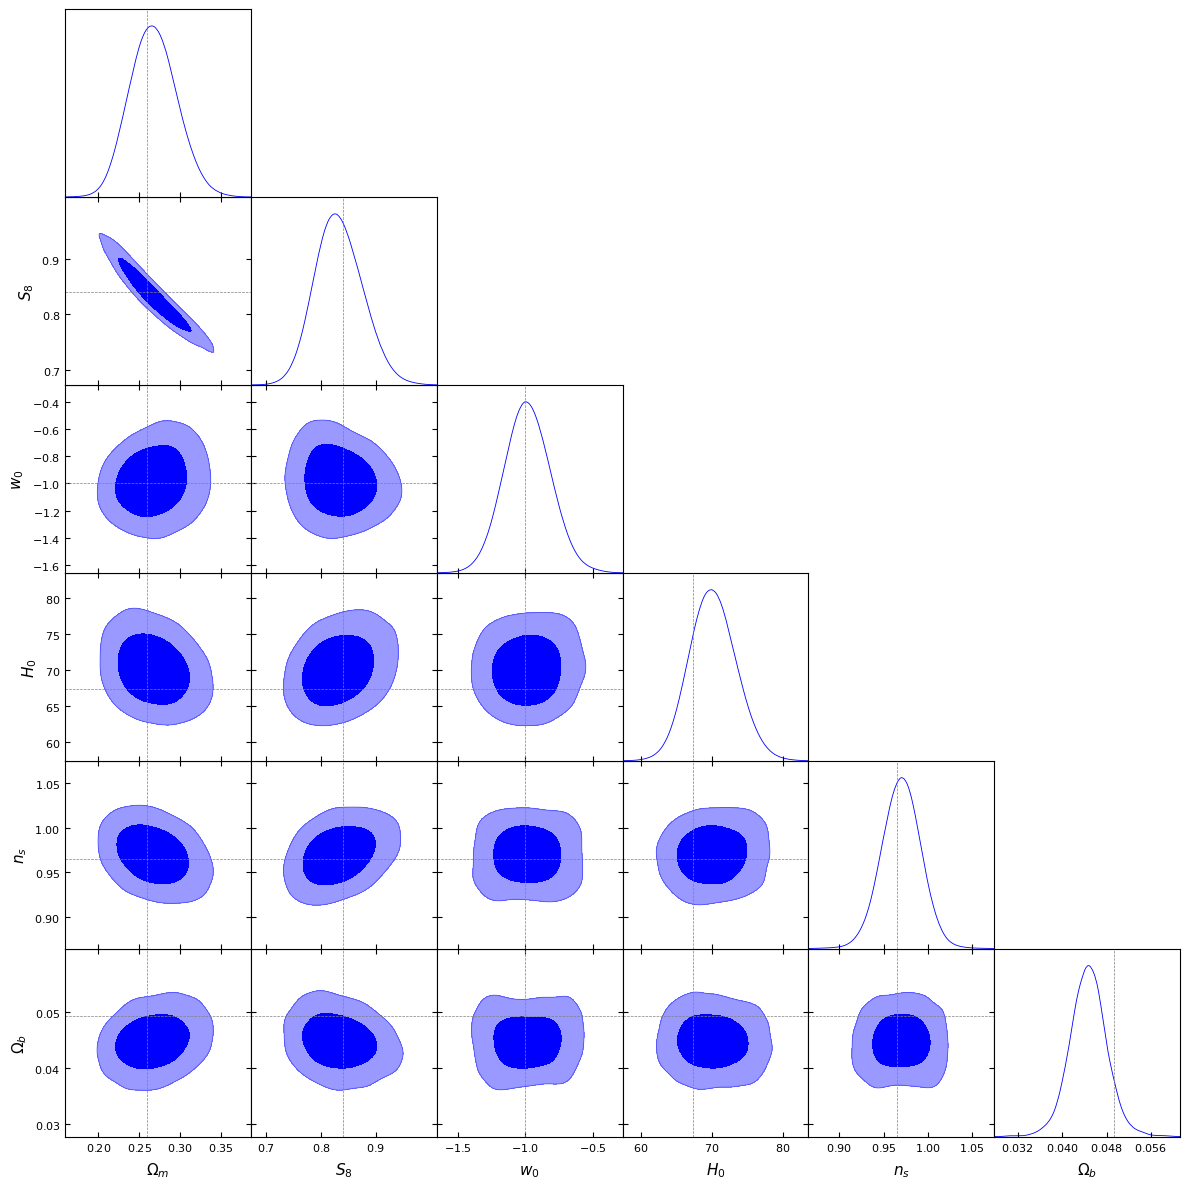

In [119]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2_3_4 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2+3+4",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2_3_4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [120]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2+3+4_bin1_bar_noisy_s026_npe.npy", samples_gd_scales_1_2_3_4.samples)

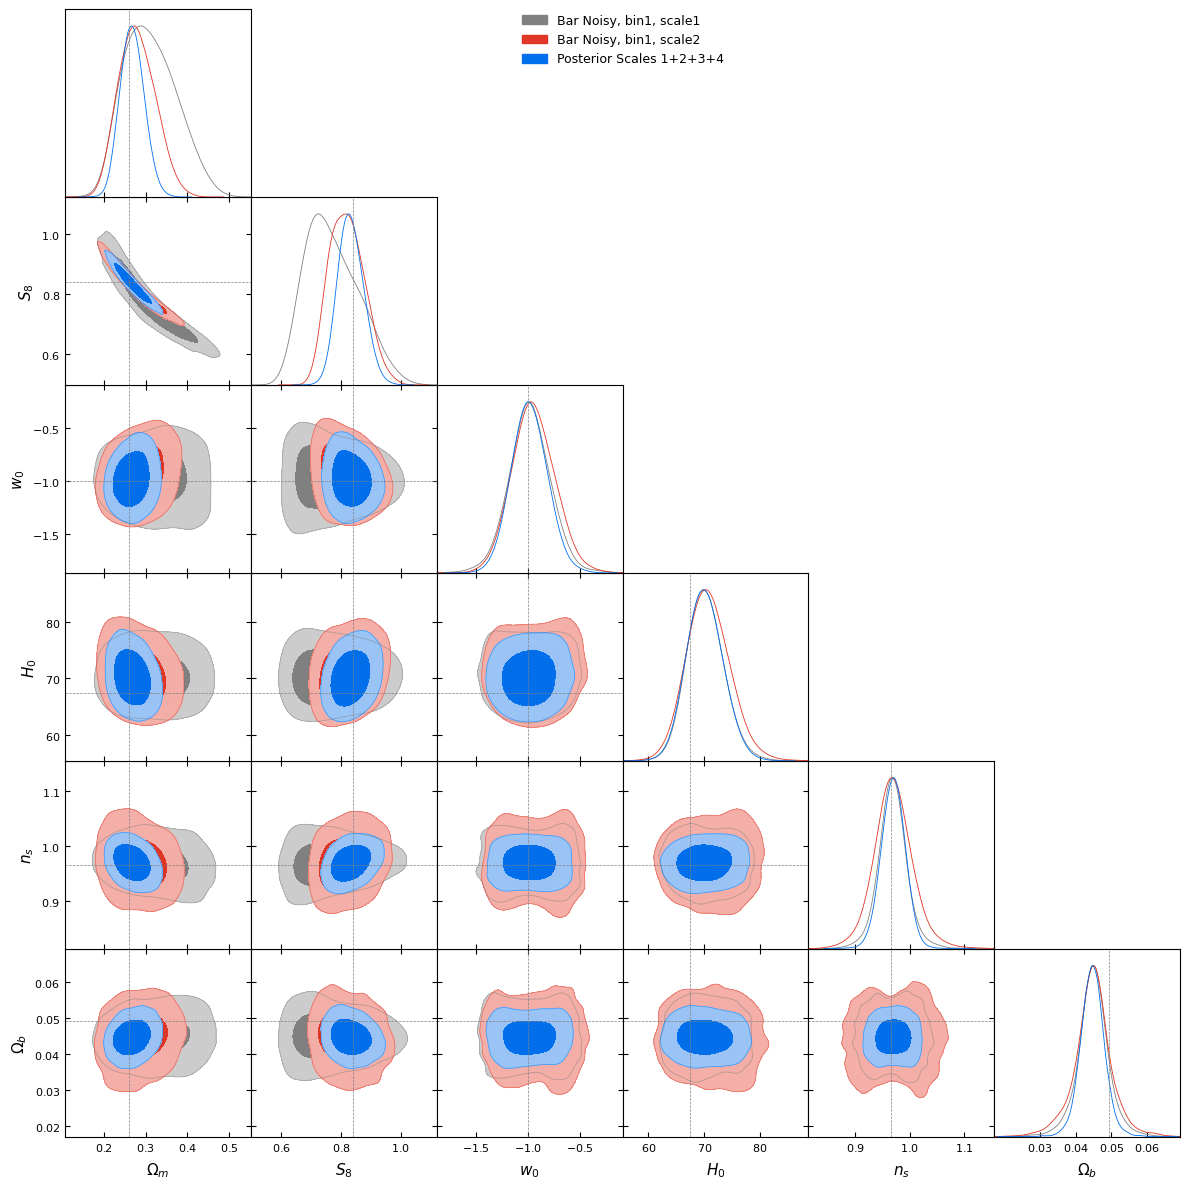

In [121]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale[0], samples_scale[1], samples_gd_scales_1_2_3_4], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## 1+2+3+4+5

In [122]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
l1_scale3 = l1_full[:, 2]
l1_scale4 = l1_full[:, 3]
l1_scale5 = l1_full[:, 4]
# combine the two scale histograms
l1_scales_1_2_3_4_5 = np.concatenate((l1_scale1, l1_scale2, l1_scale3, l1_scale4, l1_scale5), axis=1)
l1_scales_1_2_3_4_5.shape 

(16966, 200)

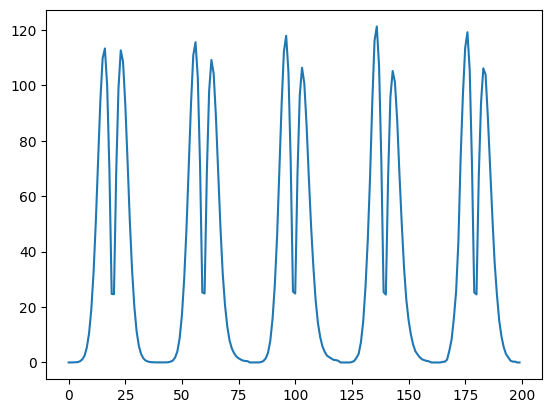

In [123]:
plt.plot(l1_scales_1_2_3_4_5[5])

In [124]:
params = jnp.array(params)
l1_scales_1_2_3_4_5 = jnp.array(l1_scales_1_2_3_4_5)
dataset = (params, l1_scales_1_2_3_4_5)

In [125]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2_3_4_5)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16966 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11876 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [126]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1+2+3+4+5_bin1_bar_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -7.121/ Best val loss -7.123:  40%|████      | 404/1000 [02:31<03:44,  2.66it/s]

Neural network training stopped after 405 epochs.
Early stopping with best validation metric: -7.12264347076416
Best model saved at epoch 384
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.370828628540039
[!] Validation loss: -7.12264347076416
[!] Test loss: -7.112490177154541


In [127]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [128]:
fid_mean_scales_1_2_3_4_5 = np.concatenate((fid_mean[0], fid_mean[1], fid_mean[2], fid_mean[3], fid_mean[4]))
fid_mean_scales_1_2_3_4_5.shape

(200,)

Sampling

In [129]:
import jax.random as random

master_key = random.PRNGKey(1)

In [130]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2_3_4_5, num_samples=num_samples, key=sample_key
)

In [131]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [132]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


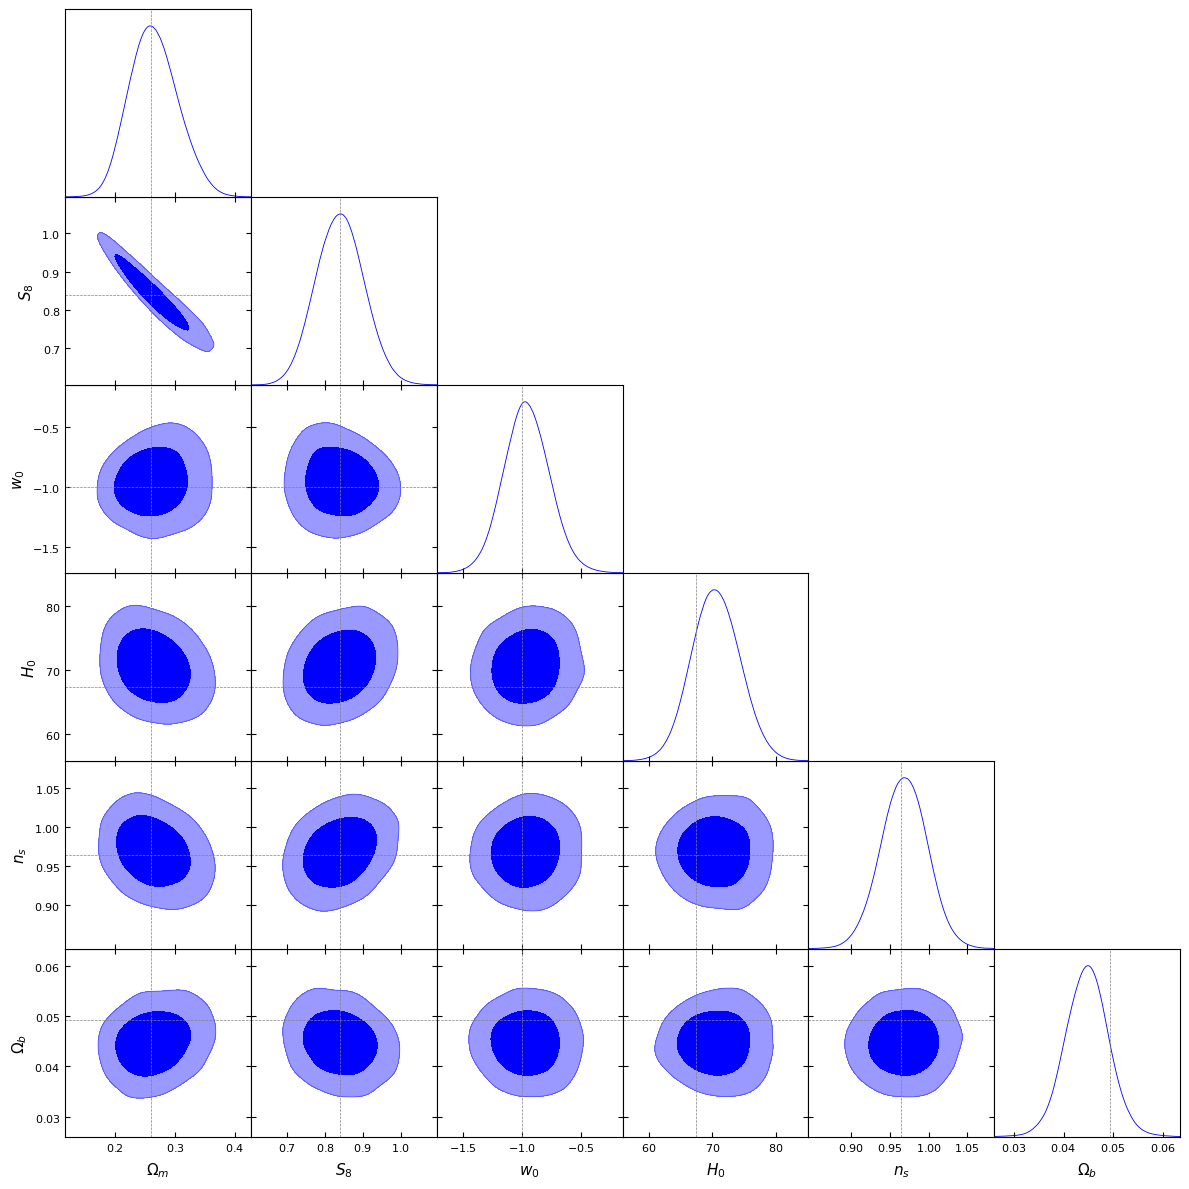

In [133]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2_3_4_5 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2+3+4+5",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2_3_4_5], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [134]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2+3+4+5_bin1_bar_noisy_s026_npe.npy", samples_gd_scales_1_2_3_4_5.samples)

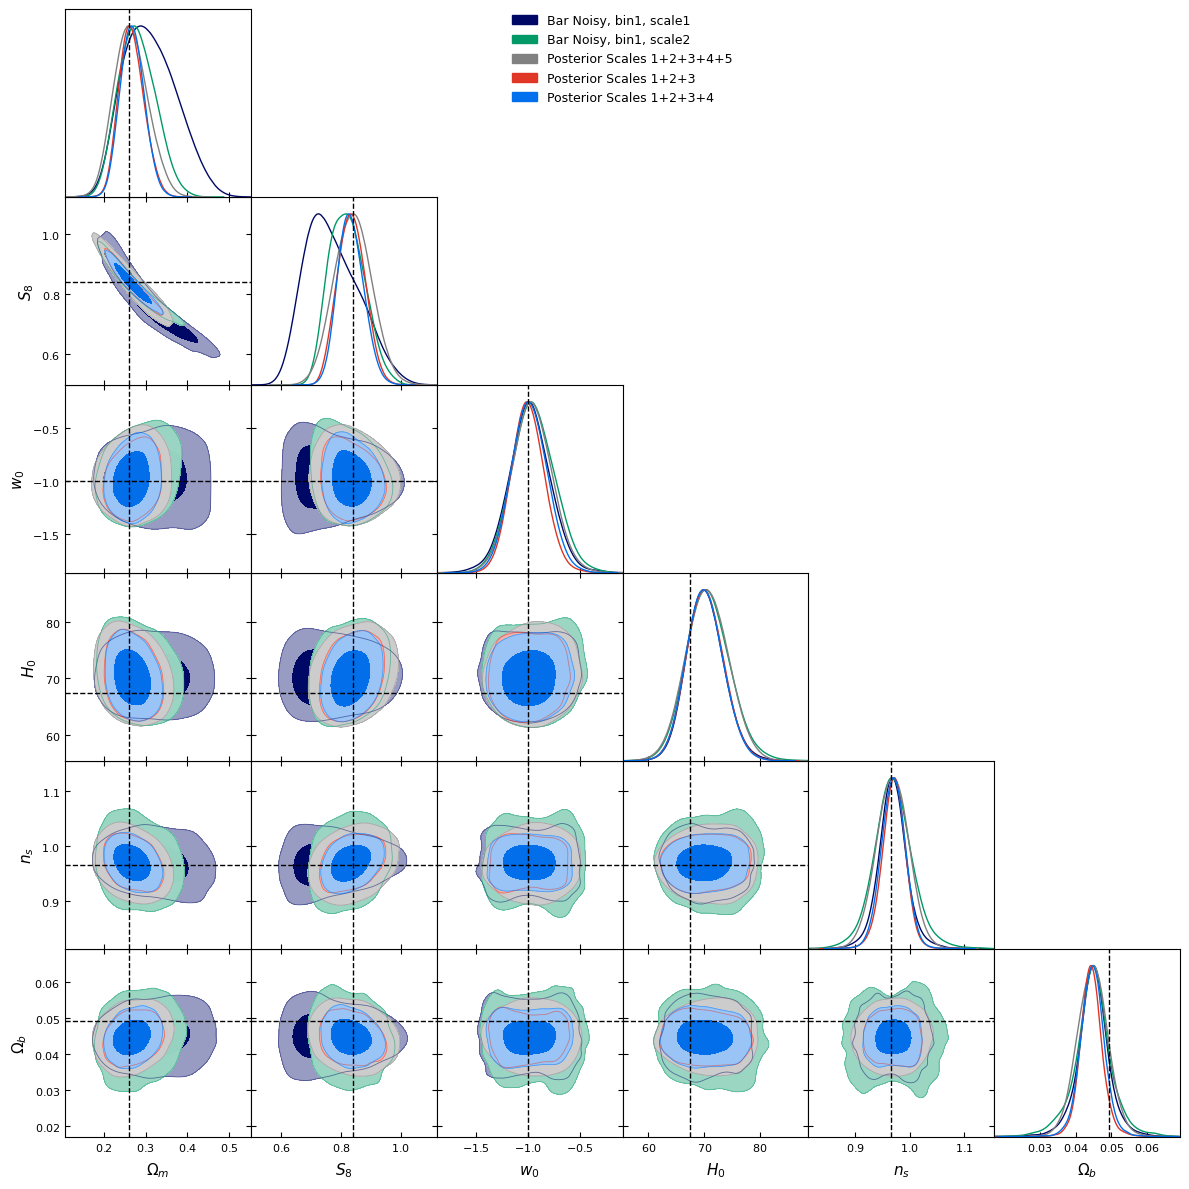

In [135]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale[0], samples_scale[1], samples_gd_scales_1_2_3_4_5, samples_gd_scales_1_2_3, samples_gd_scales_1_2_3_4], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_bar_bin1_different_scales_npe.pdf")
plt.show()

# Compare Noisy vs Noiseless Bar

In [227]:
samples_noisy = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2+3+4+5_bin1_bar_noisy_npe.npy", allow_pickle=True)
samples_noiseless = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [230]:
samples_noisy = MCSamples(
    samples=samples_noisy,
    names=labels,
    label="Bar, bin1, noisy (1+2+3+4)",
)
samples_noiseless = MCSamples(
    samples=samples_noiseless,
    names=labels,
    label="Bar, bin1, noiseless, 1",
)

Removed no burn in
Removed no burn in


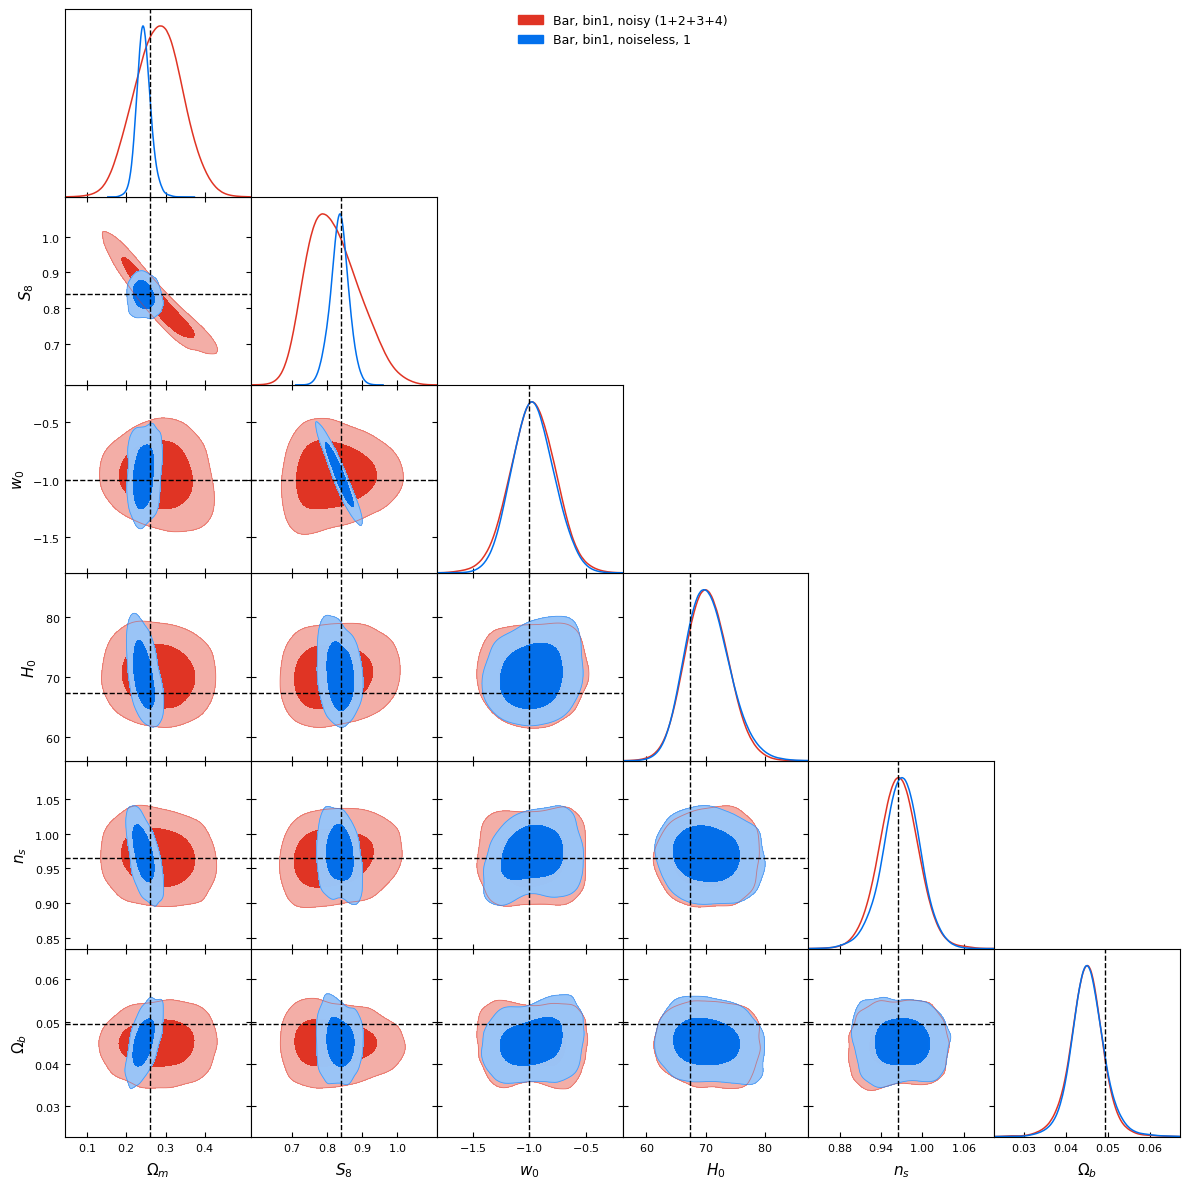

In [231]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_noisy, samples_noiseless], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noiseless_vs_noisy_bin1_bar_npe.pdf")
plt.show()

# **NO BARYONS**

# SBI with cosmoGRID l1-norms

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Change "1" to the desired GPU index
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"  # Use 50% of GPU memory
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

from jaxili.inference import NPE

# device = jax.devices("gpu")[0] 
print("Device used by jax:", jax.devices())

# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform" # Avoids preallocation of GPU memory

Device used by jax: [CudaDevice(id=0)]


In [138]:
params = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_params.npy', allow_pickle=True)

# **BIN 1**

In [3]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin1_nobaryons_noisy_s026.npy', allow_pickle=True)

In [4]:
params.shape, l1_full.shape

((16965, 6), (16965, 5, 40))

## Scale 1

In [5]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16965, 40)

In [6]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [7]:
dataset = (params, l1_scale1)

In [8]:
inference = NPE()

In [9]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [10]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale1_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -4.504/ Best val loss -5.716:  13%|█▎        | 126/1000 [00:48<05:38,  2.58it/s]

Neural network training stopped after 127 epochs.
Early stopping with best validation metric: -5.715946674346924
Best model saved at epoch 106
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -5.804656982421875
[!] Validation loss: -5.715946674346924
[!] Test loss: -6.118871688842773


In [11]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [13]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_nobaryons_fid_bin1_noisy_s026.npy', allow_pickle=True)

In [14]:
np.array(fid_full).shape

(200, 5, 40)

In [15]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [16]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [17]:
import jax.random as random

master_key = random.PRNGKey(1)

In [18]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [19]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [20]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


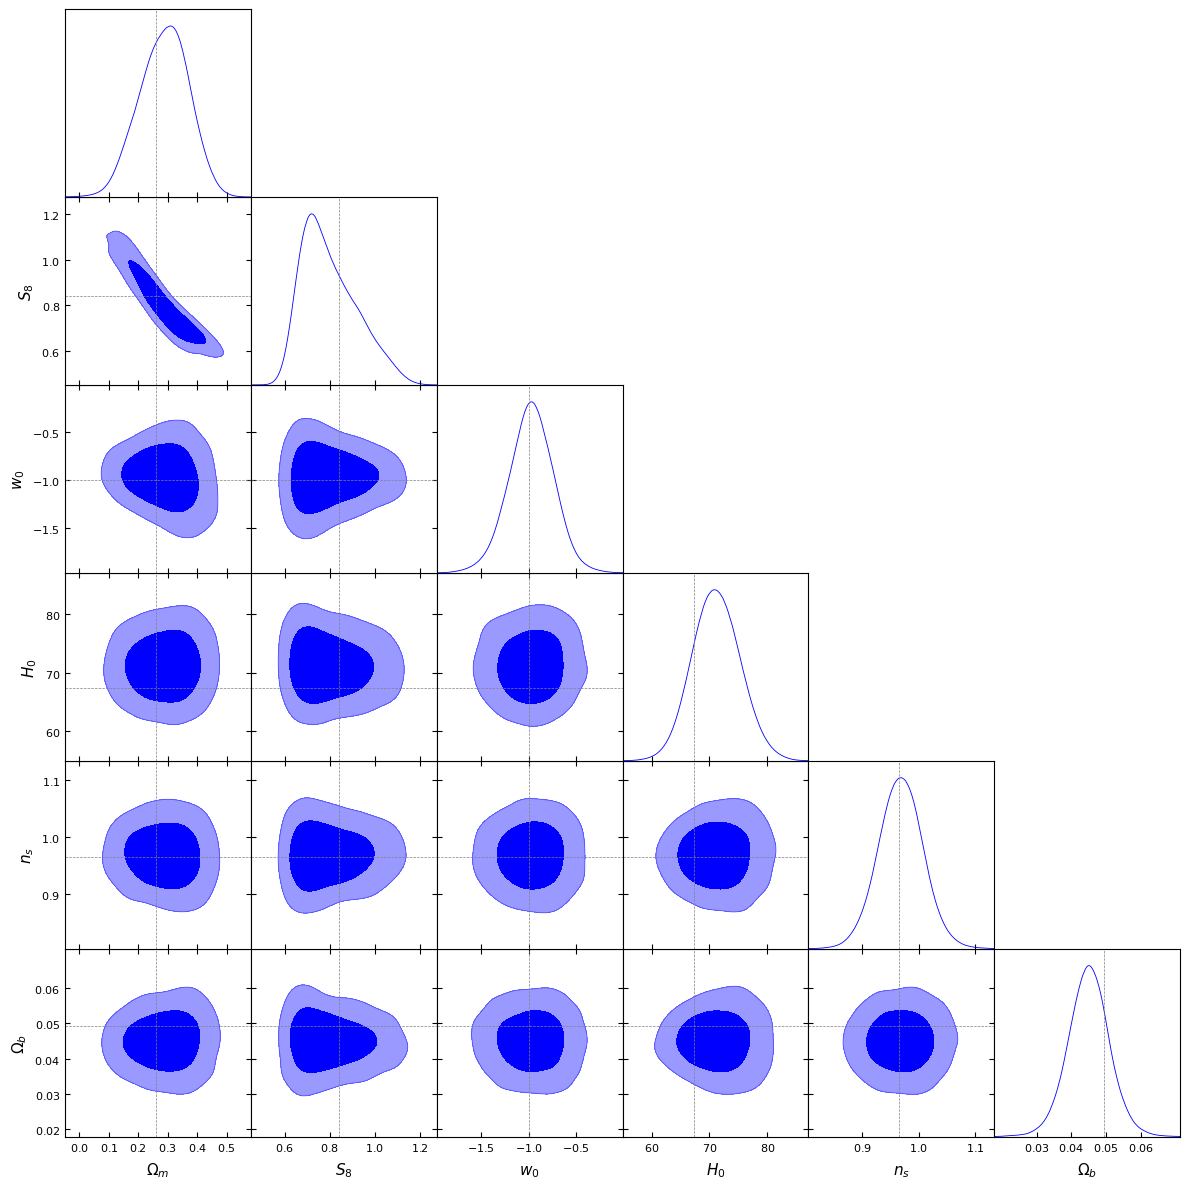

In [21]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="NoBar, bin1, scale1",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [22]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale1_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale1.samples)

## Scale 2

In [23]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16965, 40)

In [24]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)
dataset = (params, l1_scale2)

In [25]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [26]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale2_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.044/ Best val loss -7.043:  48%|████▊     | 481/1000 [02:41<02:53,  2.98it/s]

Neural network training stopped after 482 epochs.
Early stopping with best validation metric: -7.042638778686523
Best model saved at epoch 480
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.0551958084106445
[!] Validation loss: -7.043545722961426
[!] Test loss: -7.130246639251709


In [27]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [28]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [29]:
import jax.random as random

master_key = random.PRNGKey(1)

In [30]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [31]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [32]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


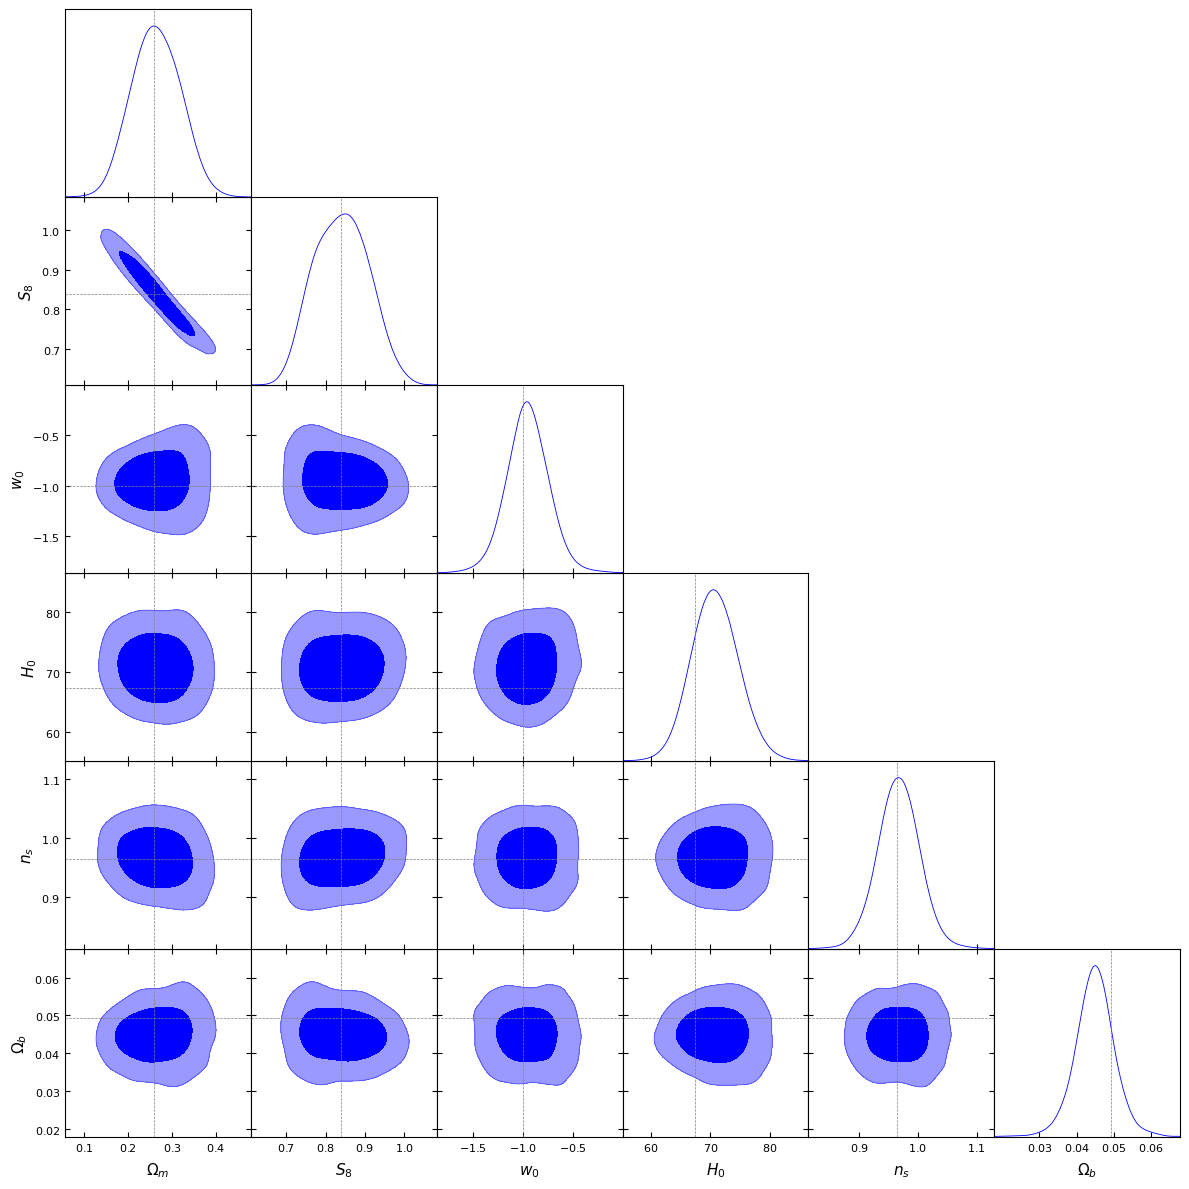

In [33]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [34]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale2_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale2.samples)

## Scale 3

In [35]:
l1_scale3 = l1_full[:, 2]
l1_scale3.shape 

(16965, 40)

In [36]:
params = jnp.array(params)
l1_scale3 = jnp.array(l1_scale3)
dataset = (params, l1_scale3)

In [37]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [38]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale3_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -6.950/ Best val loss -6.955:  23%|██▎       | 230/1000 [01:16<04:17,  2.99it/s]

Neural network training stopped after 231 epochs.
Early stopping with best validation metric: -6.954701900482178
Best model saved at epoch 210
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.0758819580078125
[!] Validation loss: -6.954701900482178
[!] Test loss: -7.027115345001221


In [39]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [40]:
fid_mean_scale3 = fid_mean[2]
fid_mean_scale3.shape

(40,)

Sampling

In [41]:
import jax.random as random

master_key = random.PRNGKey(1)

In [42]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale3, num_samples=num_samples, key=sample_key
)

In [43]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [44]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


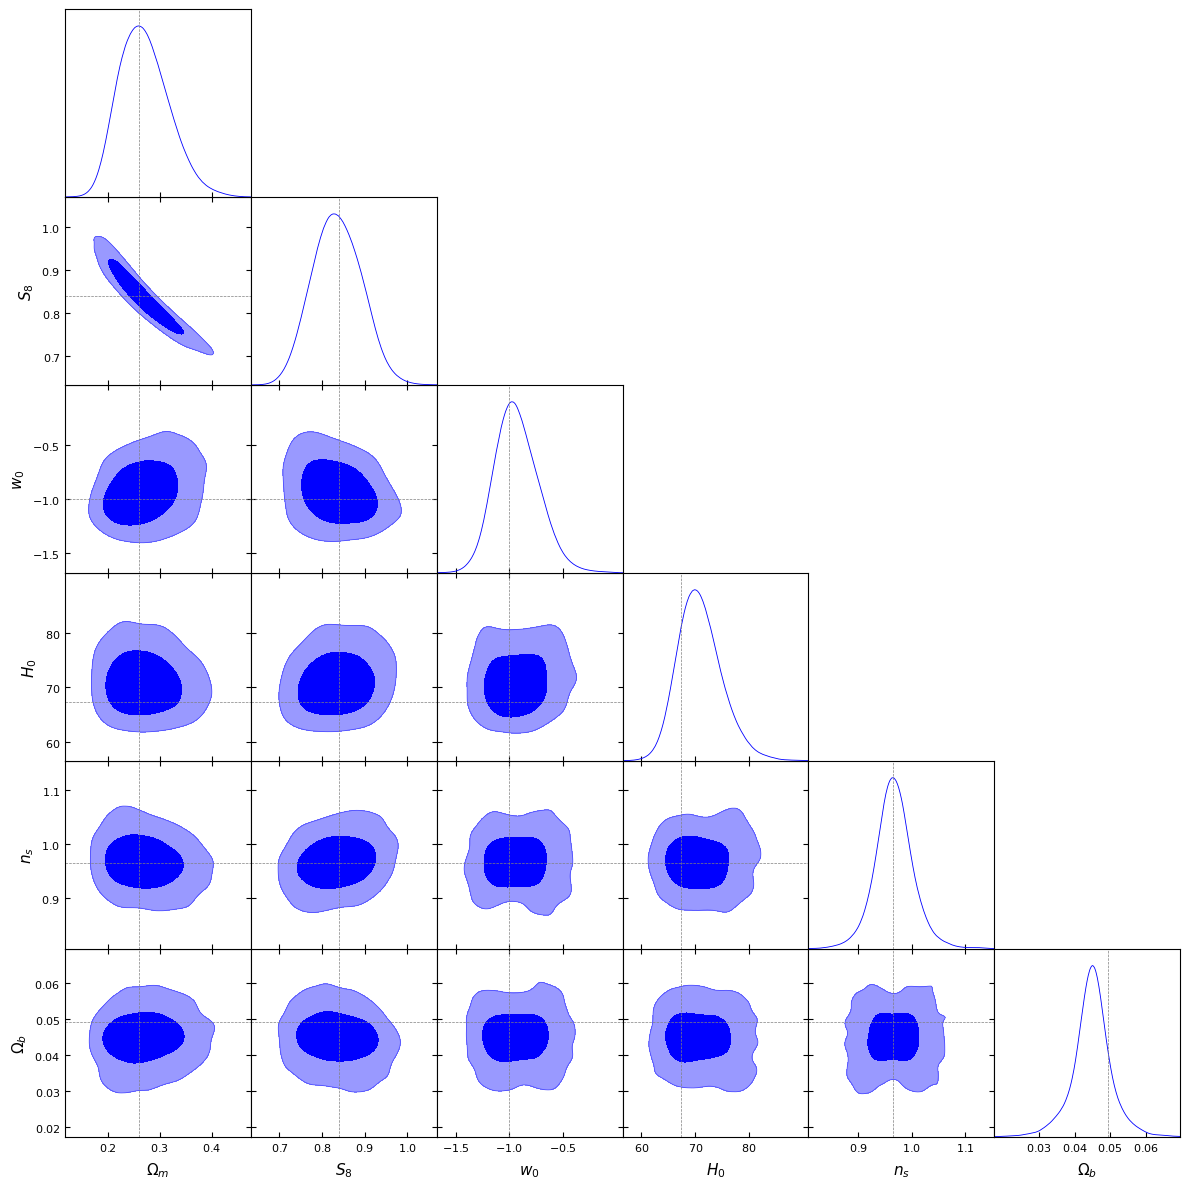

In [45]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [46]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale3_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale3.samples)

## Scale 4

In [47]:
l1_scale4 = l1_full[:, 3]
l1_scale4.shape 

(16965, 40)

In [48]:
params = jnp.array(params)
l1_scale4 = jnp.array(l1_scale4)
dataset = (params, l1_scale4)

In [49]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale4)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [50]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale4_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -6.098/ Best val loss -6.101:  16%|█▋        | 165/1000 [00:55<04:40,  2.98it/s]

Neural network training stopped after 166 epochs.
Early stopping with best validation metric: -6.1007819175720215
Best model saved at epoch 145
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -6.188258647918701
[!] Validation loss: -6.1007819175720215
[!] Test loss: -6.1412577629089355


In [51]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [52]:
fid_mean_scale4 = fid_mean[3]
fid_mean_scale4.shape

(40,)

Sampling

In [53]:
import jax.random as random

master_key = random.PRNGKey(1)

In [54]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale4, num_samples=num_samples, key=sample_key
)

In [55]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [56]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


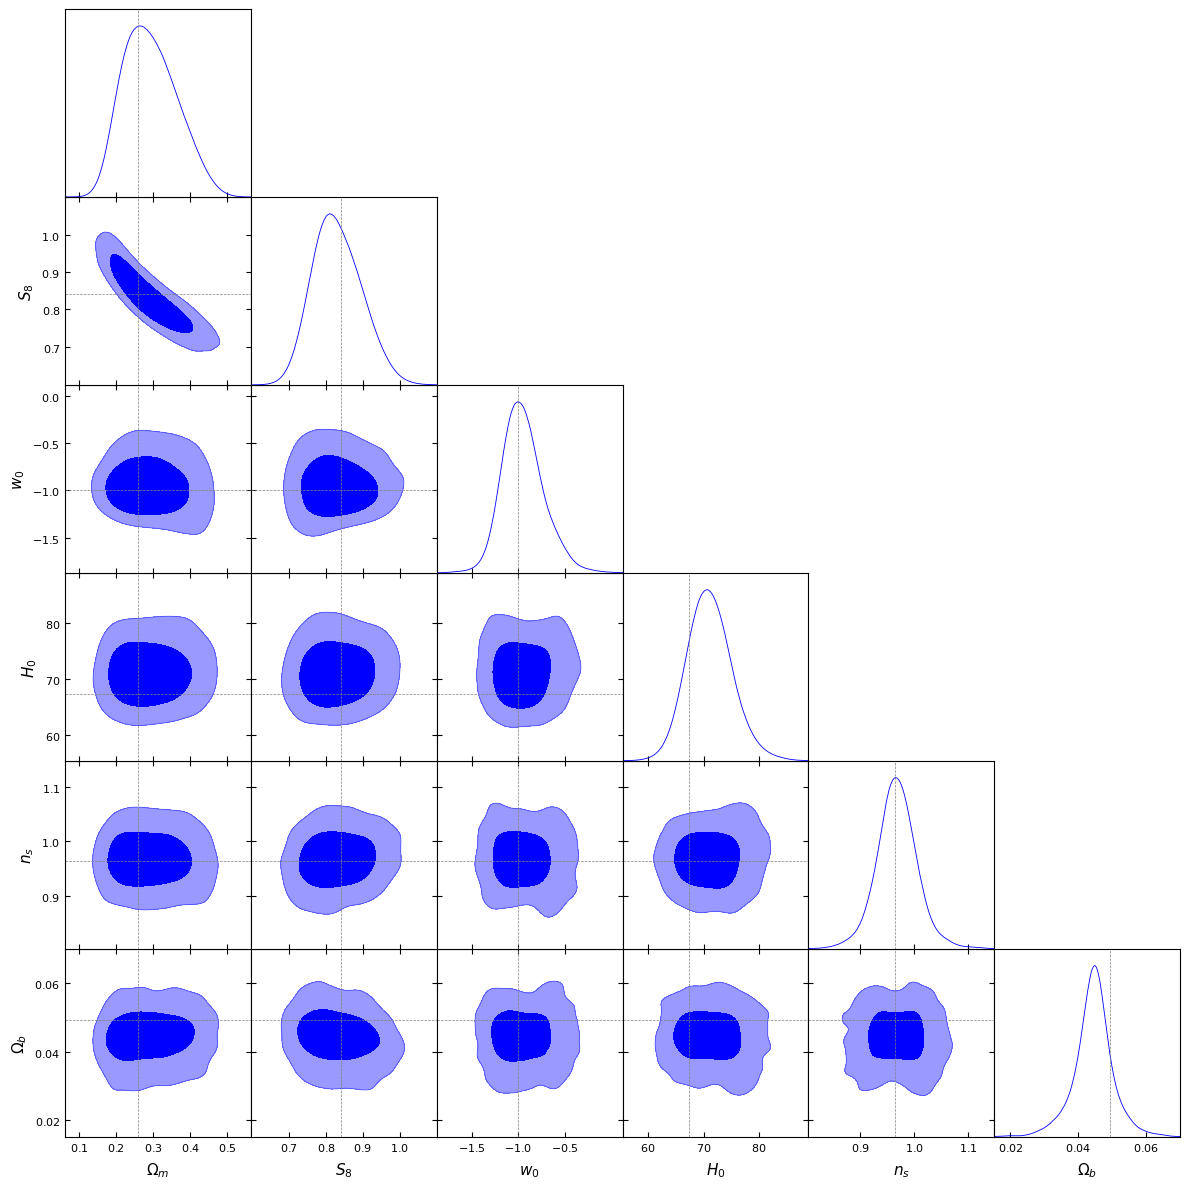

In [57]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale4 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 4",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [58]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale4_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale4.samples)

## Scale 5

In [59]:
l1_scale5 = l1_full[:, 4]
l1_scale5.shape 

(16965, 40)

In [60]:
params = jnp.array(params)
l1_scale5 = jnp.array(l1_scale5)
dataset = (params, l1_scale5)

In [61]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale5)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [62]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale5_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -5.184/ Best val loss -5.191:  11%|█         | 110/1000 [00:39<05:19,  2.79it/s]

Neural network training stopped after 111 epochs.
Early stopping with best validation metric: -5.190659523010254
Best model saved at epoch 90
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -5.234243869781494
[!] Validation loss: -5.190659523010254
[!] Test loss: -5.245431423187256


In [63]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [64]:
fid_mean_scale5 = fid_mean[4]
fid_mean_scale5.shape

(40,)

Sampling

In [65]:
import jax.random as random

master_key = random.PRNGKey(1)

In [66]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale5, num_samples=num_samples, key=sample_key
)

In [67]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [68]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


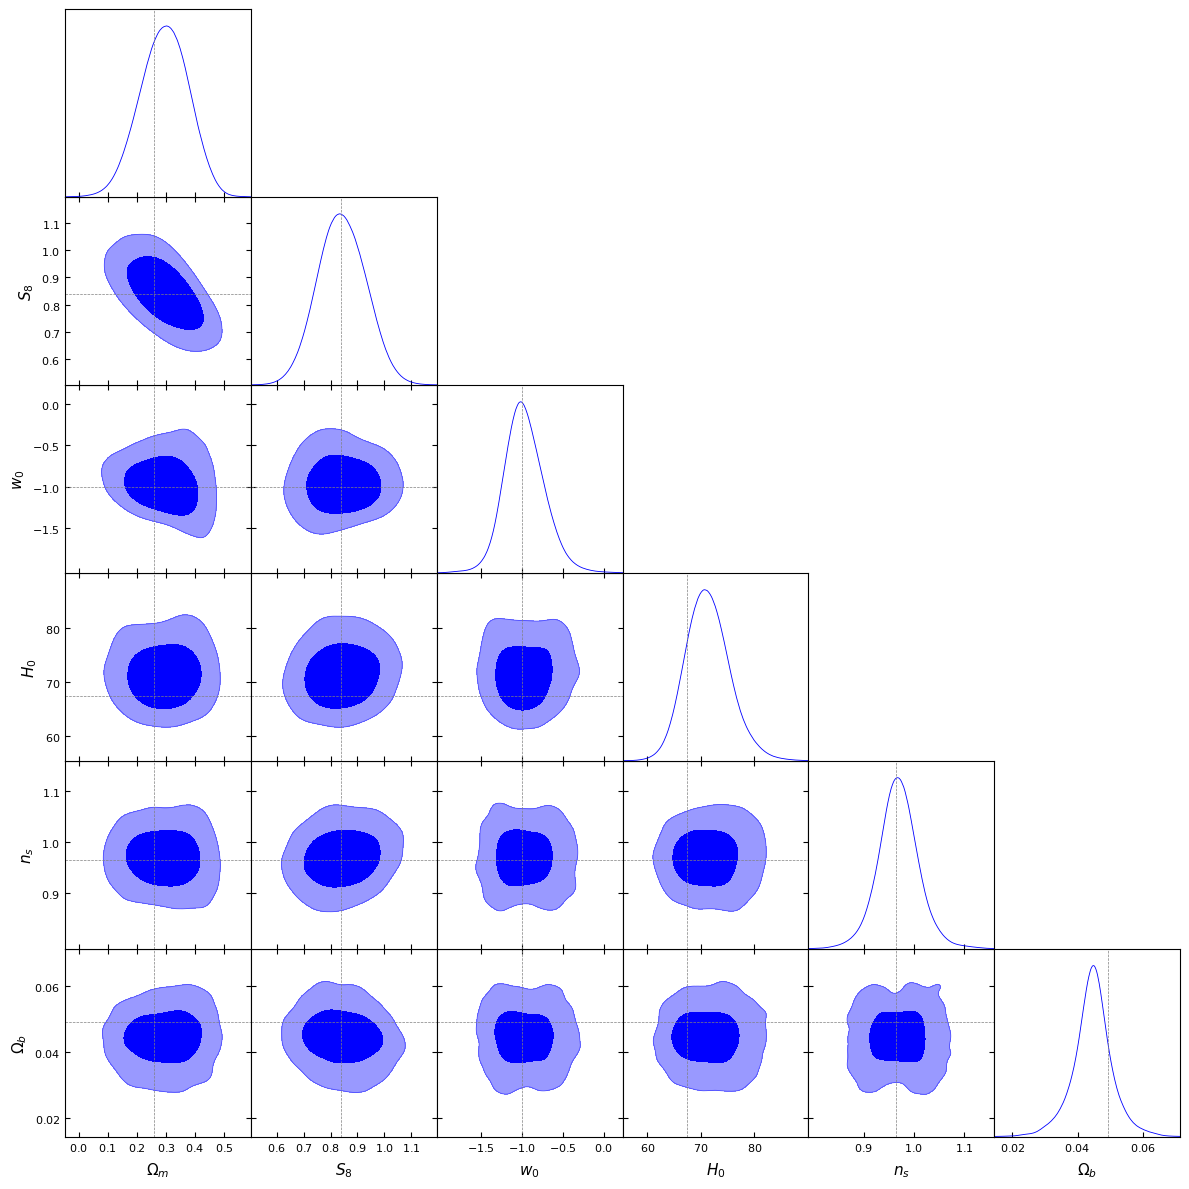

In [69]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale5 = MCSamples(
    samples=samples,
    names=labels,
    label="Bar, bin1, 5",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale5], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [70]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale5_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale5.samples)

### Compare scales

In [74]:
samples1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale1_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale2_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples3 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale3_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples4 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale4_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples5 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale5_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_nobar = [samples1, samples2, samples3, samples4, samples5]

In [75]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]
samples_scale_nobar = []
for i in range(5):
    samples_scale_i = MCSamples(samples=samples_nobar[i], names=labels, label=f"NoBar Noisy, bin1, scale{i+1}")
    samples_scale_nobar.append(samples_scale_i)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


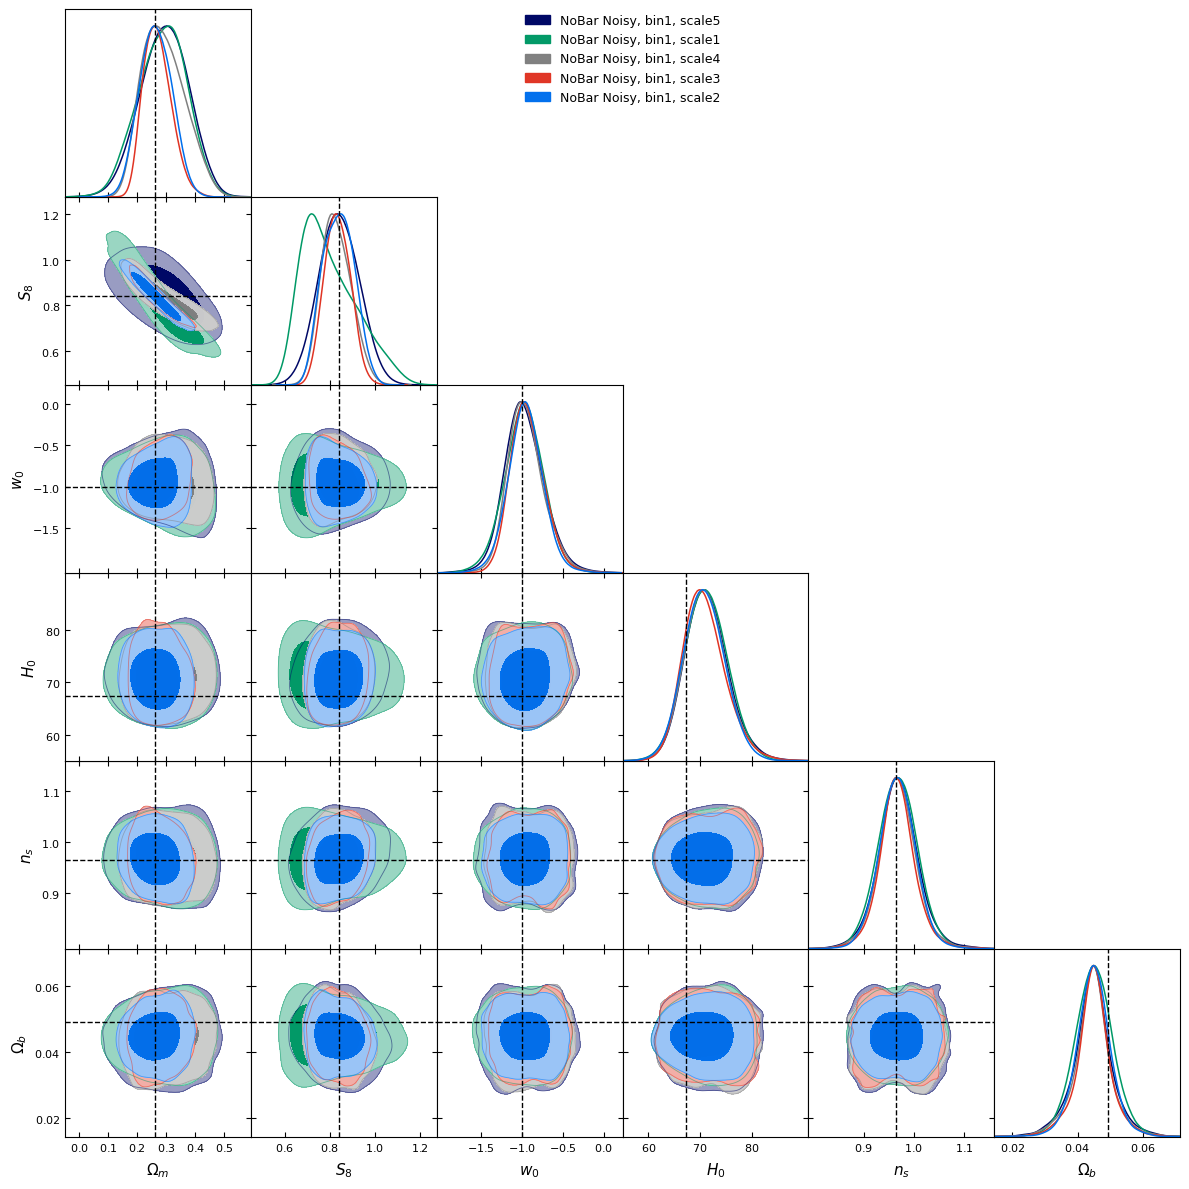

In [77]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale_nobar[4], samples_scale_nobar[0], samples_scale_nobar[3], samples_scale_nobar[2], samples_scale_nobar[1]], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/posterior_triangle_plot_each_scale_bin1)noisy_s026_npe.pdf")
plt.show()

# Combine Scales

## 1+2

In [78]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
# combine the two scale histograms
l1_scales_1_2 = np.concatenate((l1_scale1, l1_scale2), axis=1)
l1_scales_1_2.shape 

(16965, 80)

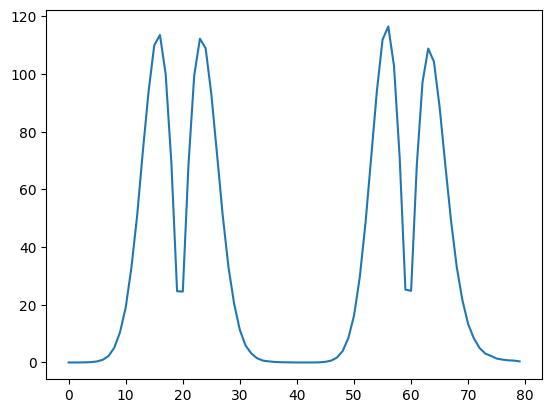

In [79]:
plt.plot(l1_scales_1_2[5])

In [80]:
params = jnp.array(params)
l1_scales_1_2 = jnp.array(l1_scales_1_2)
dataset = (params, l1_scales_1_2)

In [81]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [82]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1_2_nobar_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -8.023/ Best val loss -8.119:  12%|█▎        | 125/1000 [00:43<05:05,  2.86it/s]

Neural network training stopped after 126 epochs.
Early stopping with best validation metric: -8.118998527526855
Best model saved at epoch 105
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -8.434859275817871
[!] Validation loss: -8.118998527526855
[!] Test loss: -8.136357307434082


In [83]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [84]:
fid_mean_scales_1_2 = np.concatenate((fid_mean[0], fid_mean[1]))
fid_mean_scales_1_2.shape

(80,)

Sampling

In [85]:
import jax.random as random

master_key = random.PRNGKey(1)

In [86]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2, num_samples=num_samples, key=sample_key
)

In [87]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [88]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


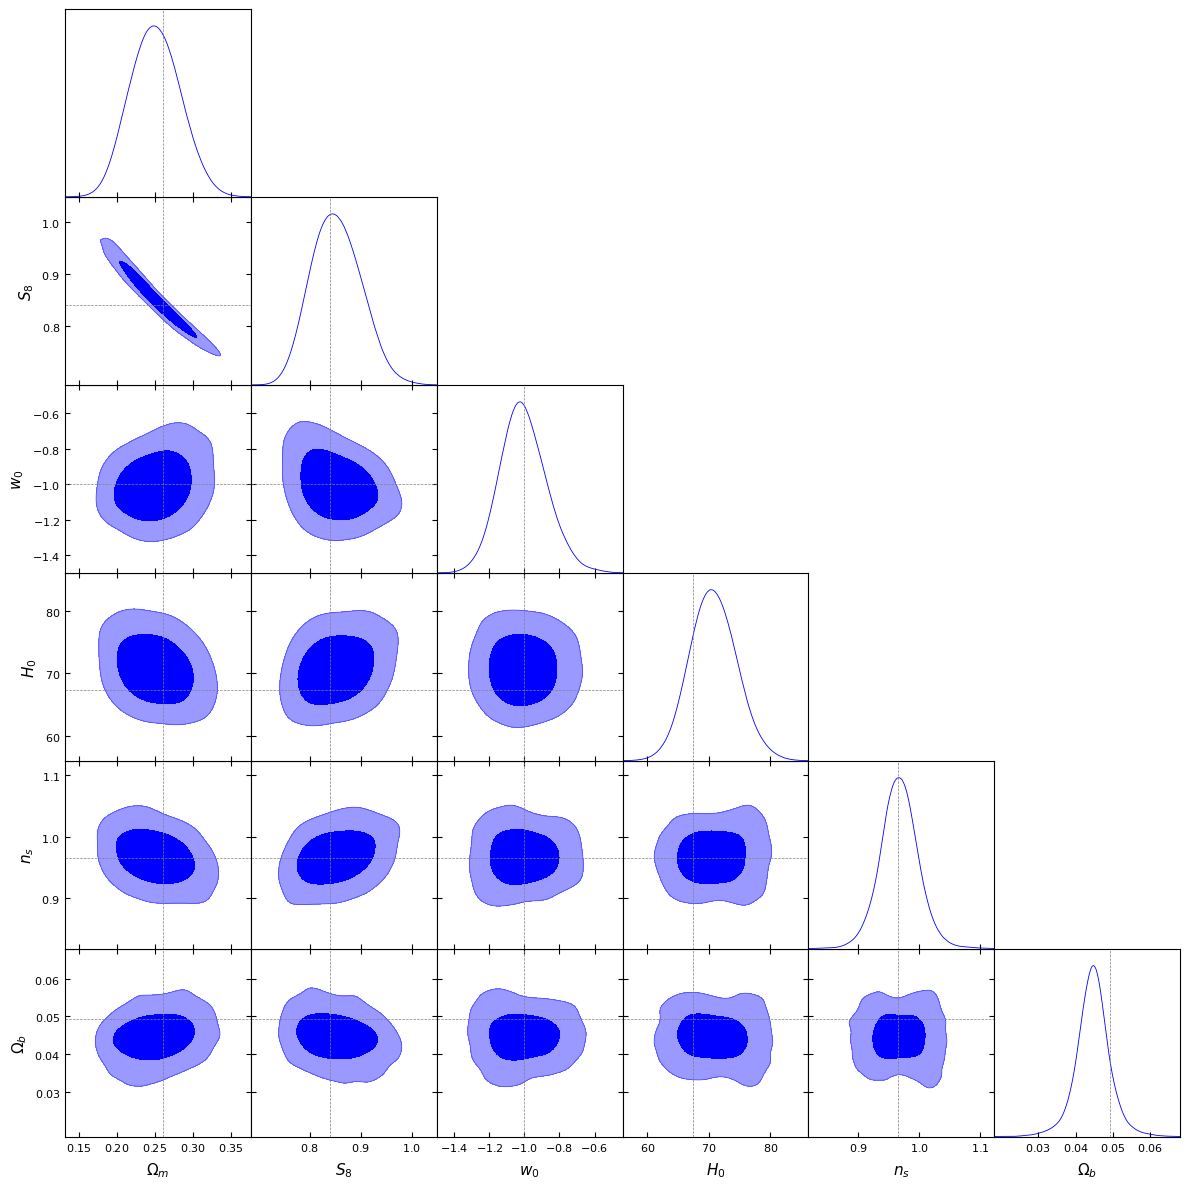

In [89]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2, Bin1, NoBar, Noisy",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [90]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2_bin1_nobar_noisy_s026_npe.npy", samples_gd_scales_1_2.samples)

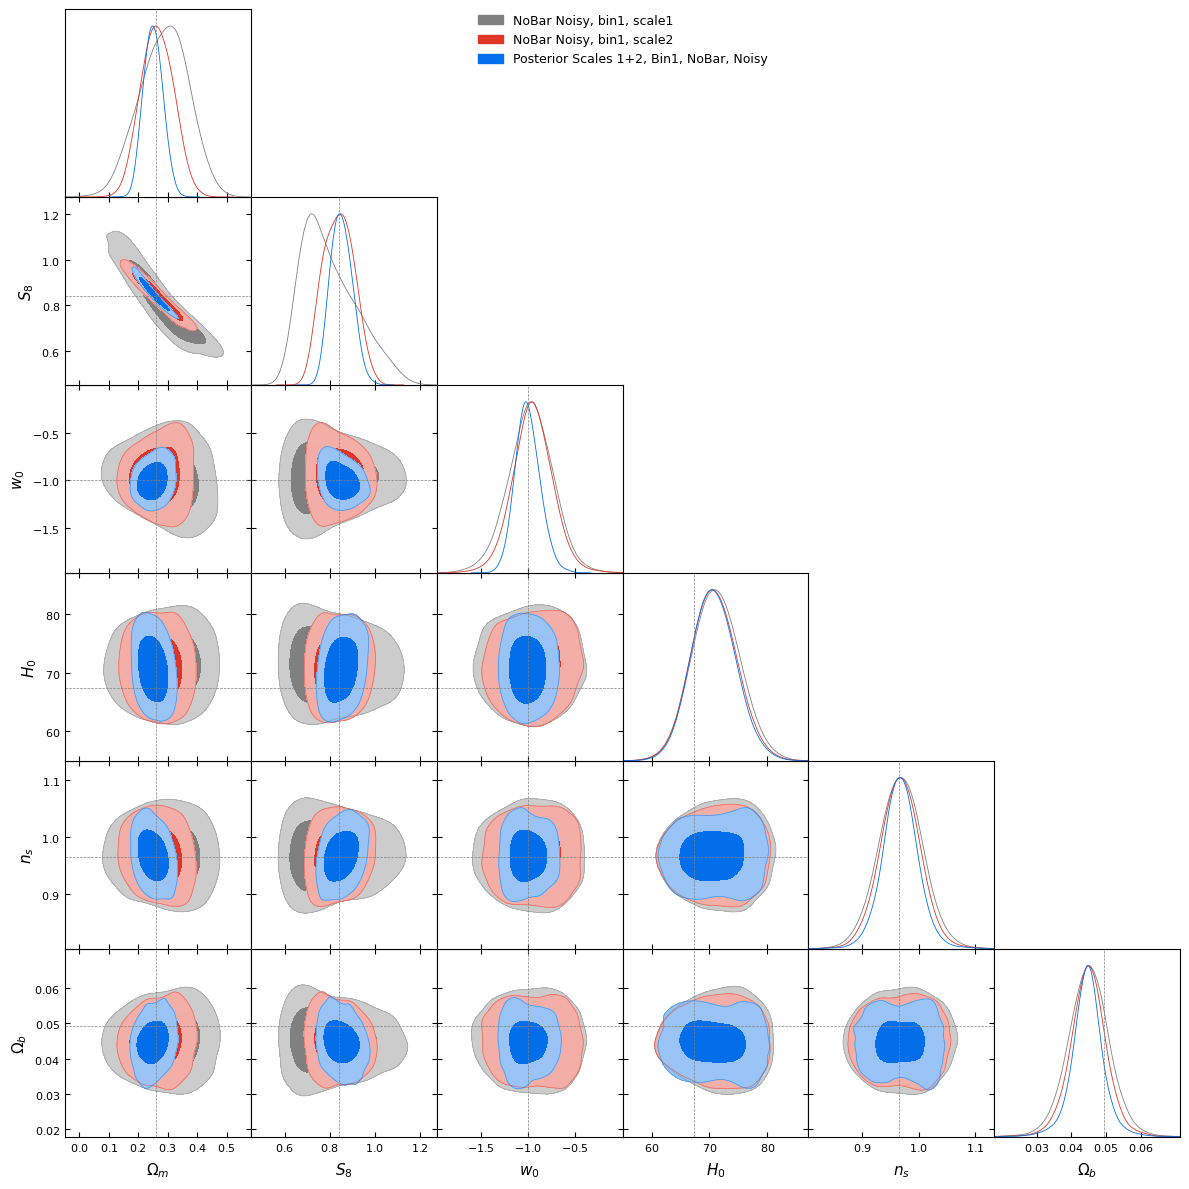

In [91]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale_nobar[0], samples_scale_nobar[1], samples_gd_scales_1_2], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## 1+2+3

In [92]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
l1_scale3 = l1_full[:, 2]
# combine the two scale histograms
l1_scales_1_2_3 = np.concatenate((l1_scale1, l1_scale2, l1_scale3), axis=1)
l1_scales_1_2_3.shape 

(16965, 120)

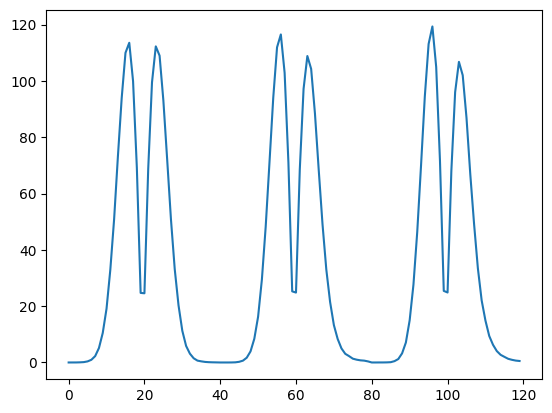

In [93]:
plt.plot(l1_scales_1_2_3[5])

In [94]:
params = jnp.array(params)
l1_scales_1_2_3 = jnp.array(l1_scales_1_2_3)
dataset = (params, l1_scales_1_2_3)

In [95]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2_3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [96]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1+2+3_bin1_nobar_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -8.050/ Best val loss -8.141:  14%|█▍        | 141/1000 [00:51<05:11,  2.76it/s]

Neural network training stopped after 142 epochs.
Early stopping with best validation metric: -8.14076042175293
Best model saved at epoch 121
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -8.589444160461426
[!] Validation loss: -8.14076042175293
[!] Test loss: -8.208592414855957


In [97]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [98]:
fid_mean_scales_1_2_3 = np.concatenate((fid_mean[0], fid_mean[1], fid_mean[2]))
fid_mean_scales_1_2_3.shape

(120,)

Sampling

In [99]:
import jax.random as random

master_key = random.PRNGKey(1)

In [100]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2_3, num_samples=num_samples, key=sample_key
)

In [101]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [102]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


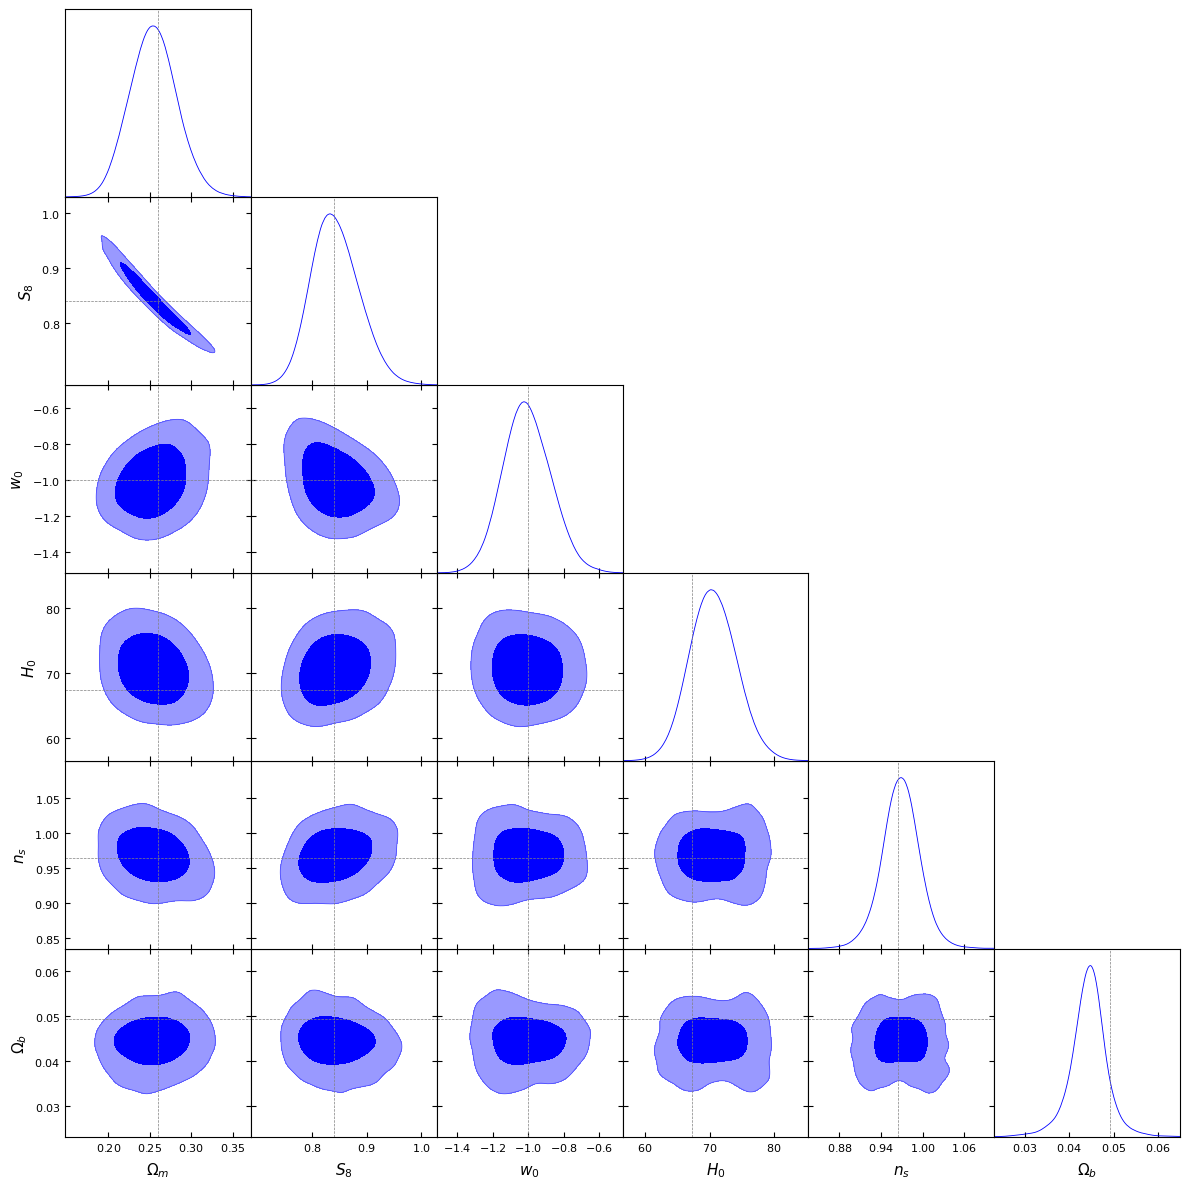

In [103]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2_3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2+3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2_3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [104]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2+3_bin1_nobar_noisy_s026_npe.npy", samples_gd_scales_1_2_3.samples)

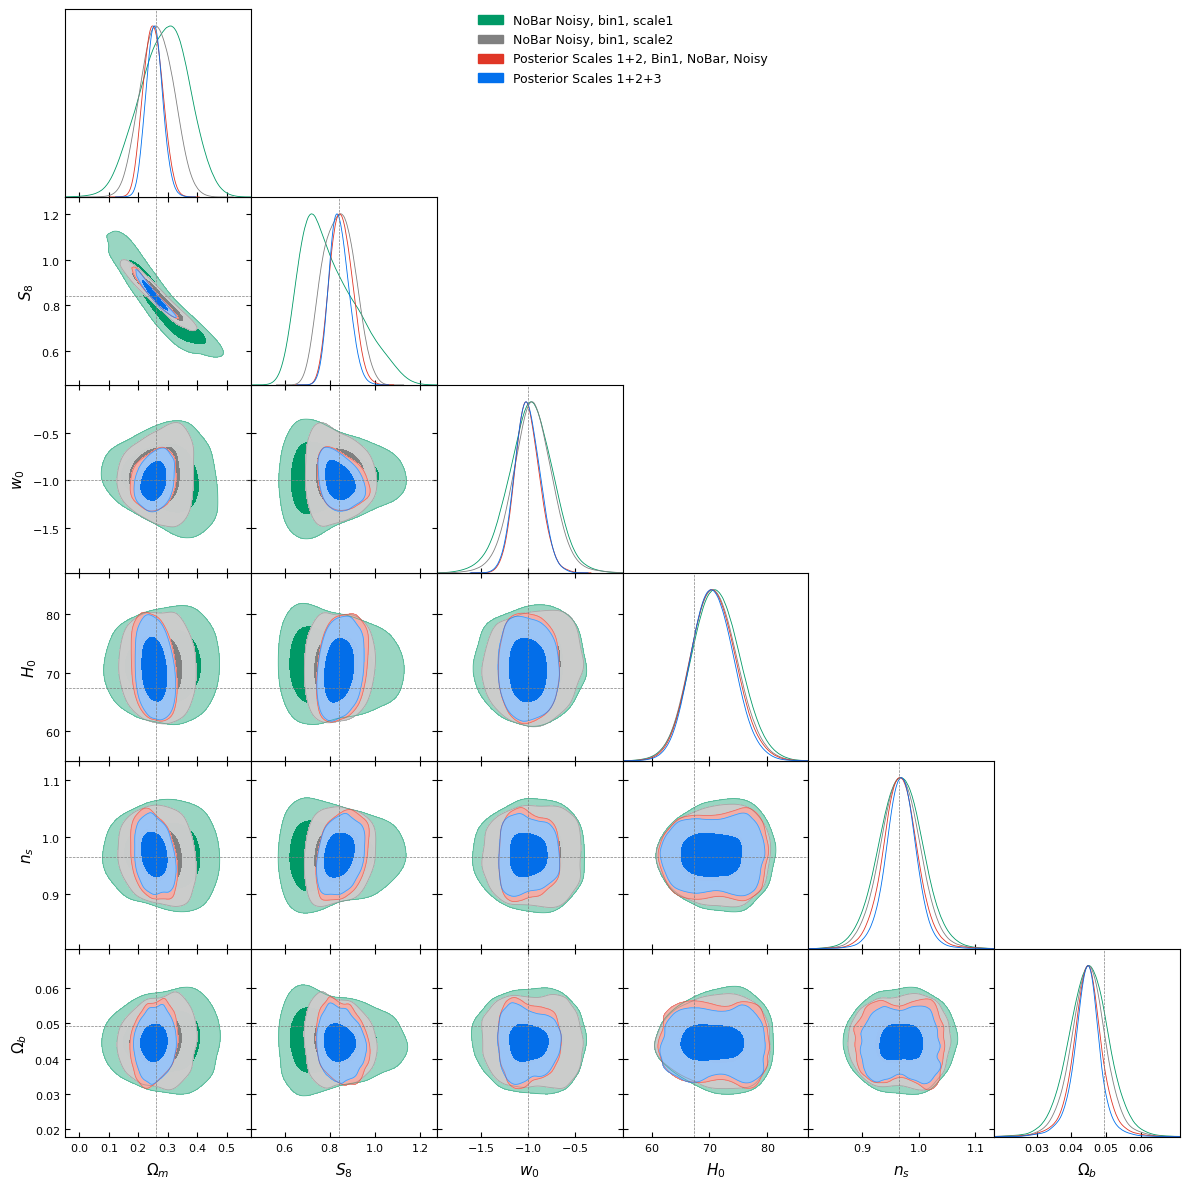

In [105]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale_nobar[0], samples_scale_nobar[1], samples_gd_scales_1_2, samples_gd_scales_1_2_3], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## 1+2+3+4

In [106]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
l1_scale3 = l1_full[:, 2]
l1_scale4 = l1_full[:, 3]
# combine the two scale histograms
l1_scales_1_2_3_4 = np.concatenate((l1_scale1, l1_scale2, l1_scale3, l1_scale4), axis=1)
l1_scales_1_2_3_4.shape 

(16965, 160)

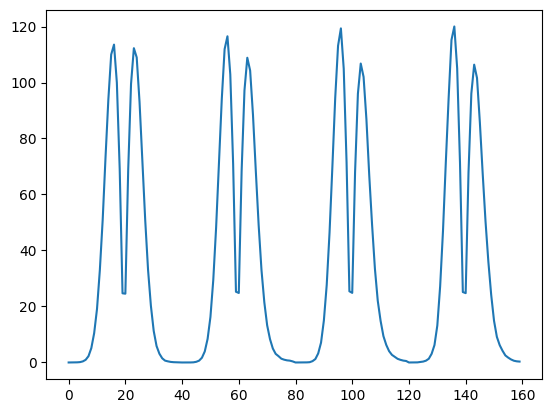

In [107]:
plt.plot(l1_scales_1_2_3_4[5])

In [108]:
params = jnp.array(params)
l1_scales_1_2_3_4 = jnp.array(l1_scales_1_2_3_4)
dataset = (params, l1_scales_1_2_3_4)

In [109]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2_3_4)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [110]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1+2+3+4_bin1_nobar_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.


[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -7.982/ Best val loss -8.055:  11%|█         | 111/1000 [00:39<05:15,  2.82it/s]

Neural network training stopped after 112 epochs.
Early stopping with best validation metric: -8.05461311340332
Best model saved at epoch 91
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -8.469527244567871
[!] Validation loss: -8.05461311340332
[!] Test loss: -8.12472915649414


In [111]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [112]:
fid_mean_scales_1_2_3_4 = np.concatenate((fid_mean[0], fid_mean[1], fid_mean[2], fid_mean[3]))
fid_mean_scales_1_2_3_4.shape

(160,)

Sampling

In [113]:
import jax.random as random

master_key = random.PRNGKey(1)

In [114]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2_3_4, num_samples=num_samples, key=sample_key
)

In [115]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [116]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


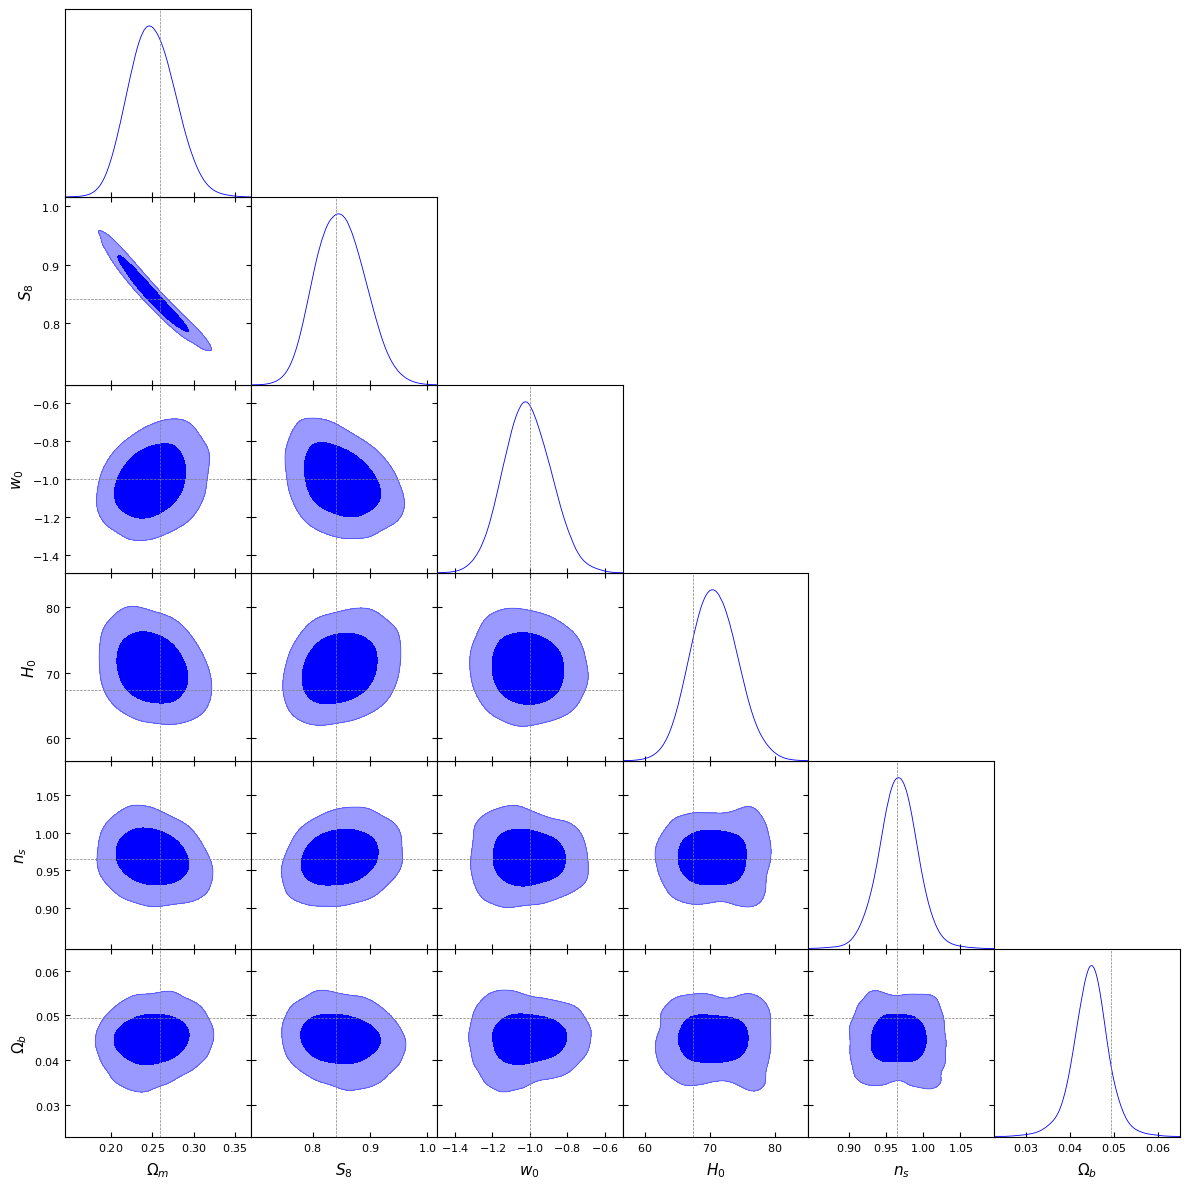

In [117]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2_3_4 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2+3+4",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2_3_4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [118]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2+3+4_bin1_nobar_noisy_s026_npe.npy", samples_gd_scales_1_2_3_4.samples)

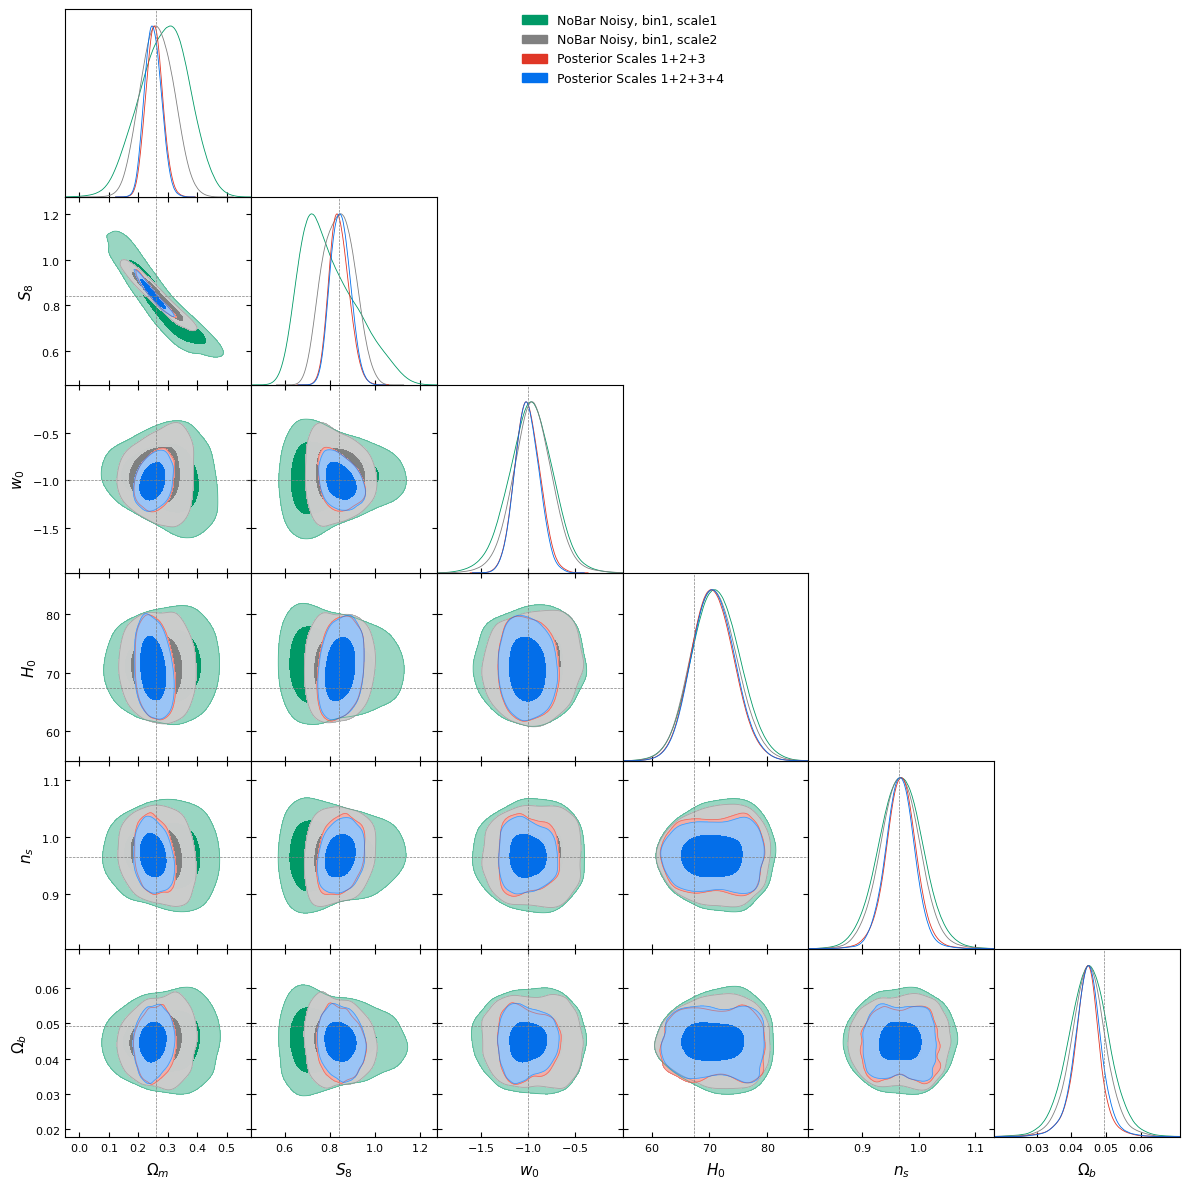

In [119]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale_nobar[0], samples_scale_nobar[1], samples_gd_scales_1_2_3, samples_gd_scales_1_2_3_4], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## 1+2+3+4+5

In [120]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
l1_scale3 = l1_full[:, 2]
l1_scale4 = l1_full[:, 3]
l1_scale5 = l1_full[:, 4]
# combine the two scale histograms
l1_scales_1_2_3_4_5 = np.concatenate((l1_scale1, l1_scale2, l1_scale3, l1_scale4, l1_scale5), axis=1)
l1_scales_1_2_3_4_5.shape 

(16965, 200)

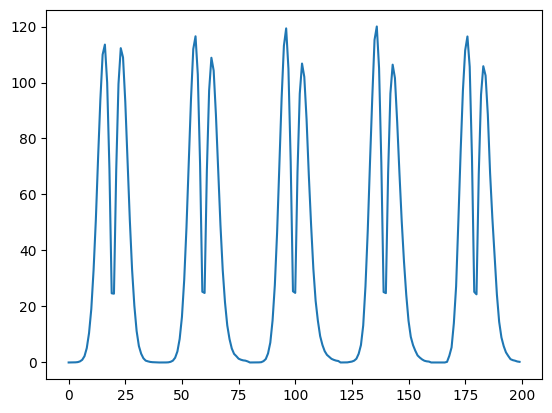

In [121]:
plt.plot(l1_scales_1_2_3_4_5[5])

In [122]:
params = jnp.array(params)
l1_scales_1_2_3_4_5 = jnp.array(l1_scales_1_2_3_4_5)
dataset = (params, l1_scales_1_2_3_4_5)

In [123]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2_3_4_5)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [124]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1+2+3+4+5_bin1_nobar_noisy"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.439/ Best val loss -7.458:  30%|██▉       | 296/1000 [01:40<03:58,  2.95it/s]

Neural network training stopped after 297 epochs.
Early stopping with best validation metric: -7.457748889923096
Best model saved at epoch 276
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.649245262145996
[!] Validation loss: -7.457748889923096
[!] Test loss: -7.412442207336426


In [125]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [126]:
fid_mean_scales_1_2_3_4_5 = np.concatenate((fid_mean[0], fid_mean[1], fid_mean[2], fid_mean[3], fid_mean[4]))
fid_mean_scales_1_2_3_4_5.shape

(200,)

Sampling

In [127]:
import jax.random as random

master_key = random.PRNGKey(1)

In [128]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2_3_4_5, num_samples=num_samples, key=sample_key
)

In [129]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [130]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


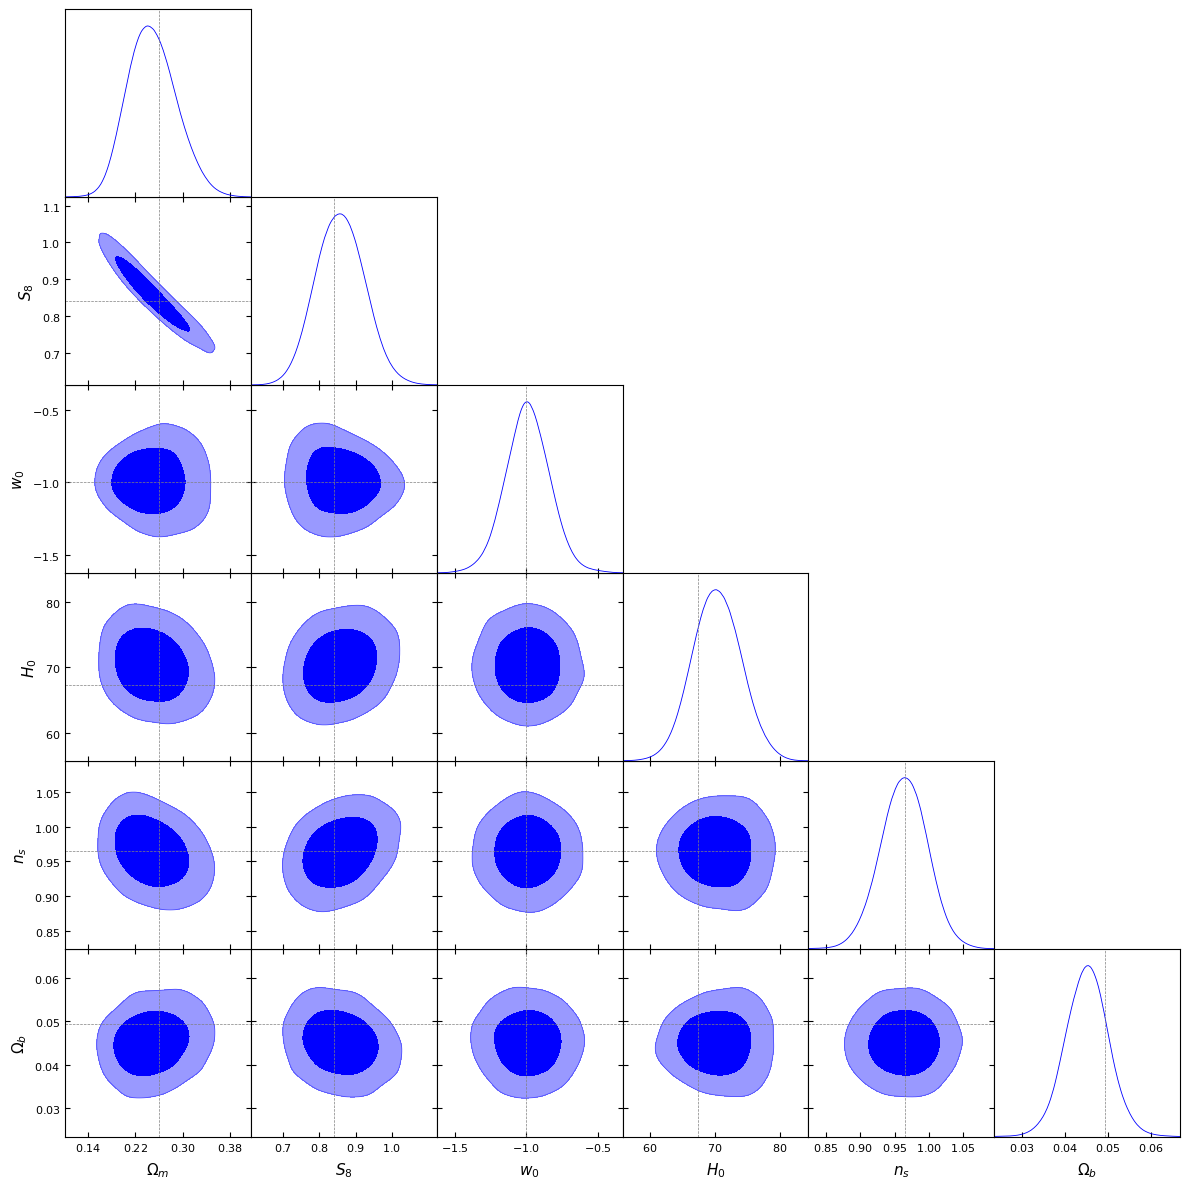

In [131]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2_3_4_5 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2+3+4+5",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2_3_4_5], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [132]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2+3+4+5_bin1_nobar_noisy_s026_npe.npy", samples_gd_scales_1_2_3_4_5.samples)

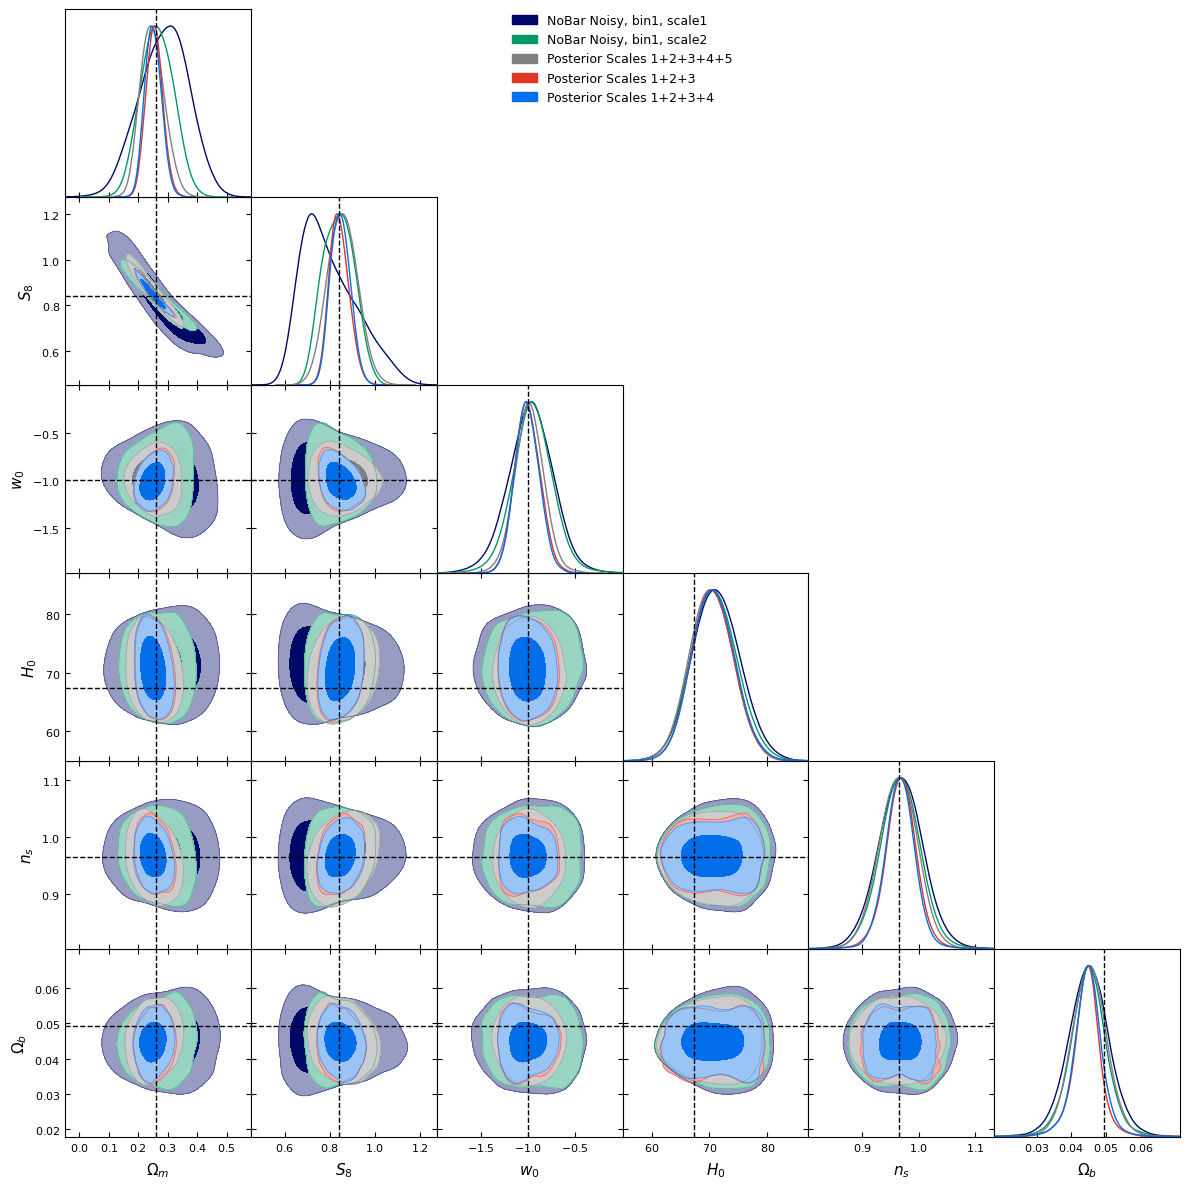

In [133]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale_nobar[0], samples_scale_nobar[1], samples_gd_scales_1_2_3_4_5, samples_gd_scales_1_2_3, samples_gd_scales_1_2_3_4], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_nobar_bin1_different_scales_npe.pdf")
plt.show()

# Compare Noisy Bar vs Noisy NoBar

## All scales

In [242]:
samples_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2+3+4+5_bin1_bar_noisy_npe.npy", allow_pickle=True)
samples_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1+2+3+4+5_bin1_nobar_noisy_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [243]:
samples_bar = MCSamples(
    samples=samples_bar,
    names=labels,
    label="Bar, bin1, noisy (all scales)",
)
samples_nobar = MCSamples(
    samples=samples_nobar,
    names=labels,
    label="NoBar, bin1, noisy, (all scales)",
)

Removed no burn in
Removed no burn in


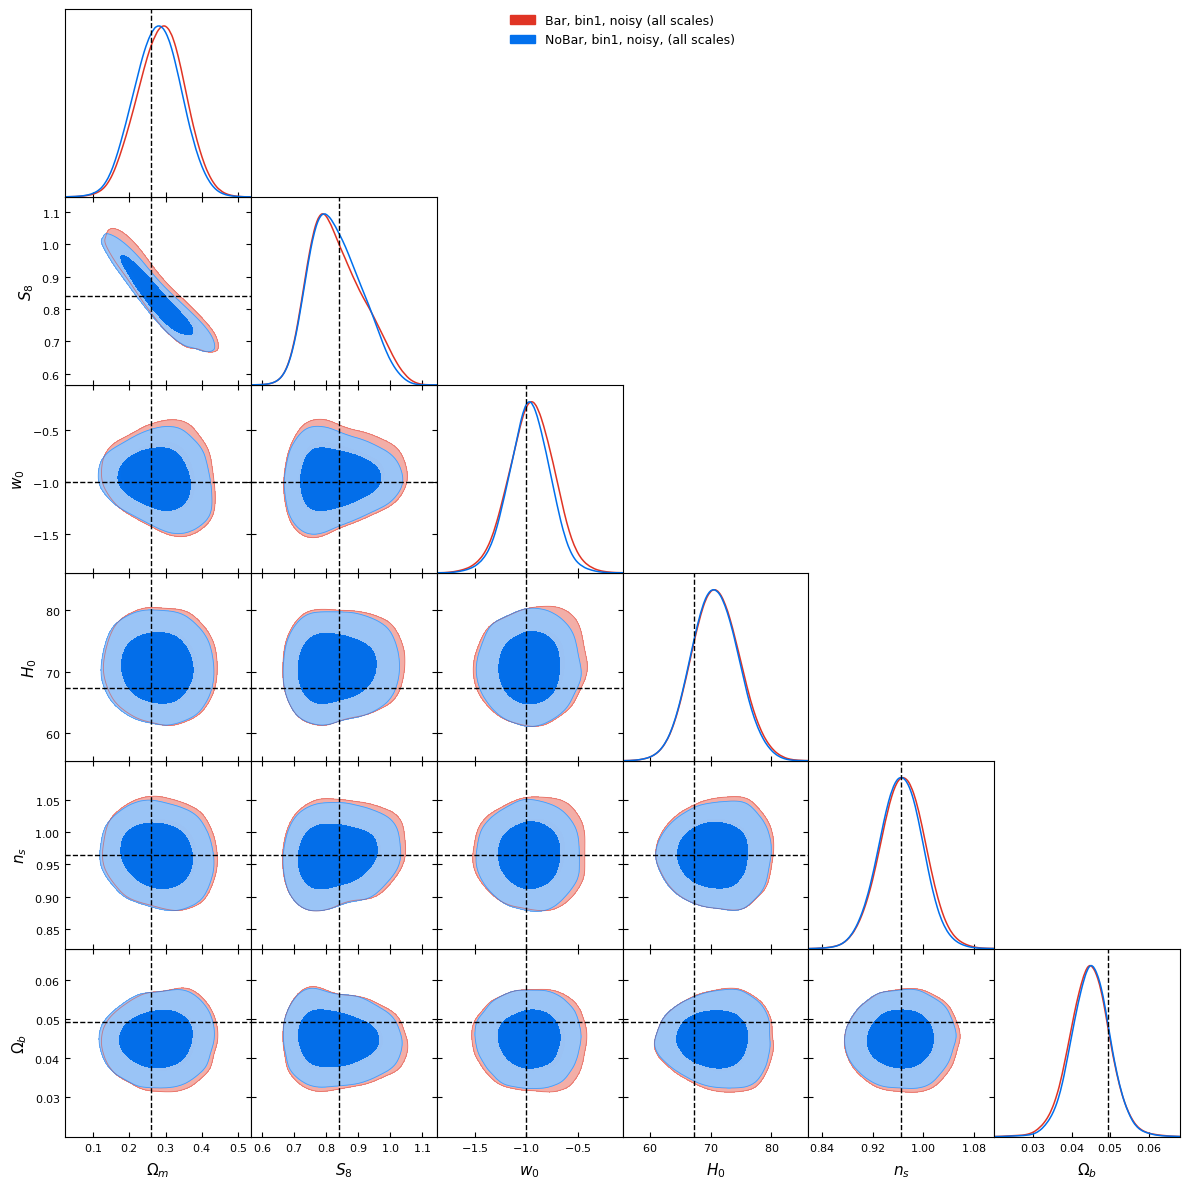

In [244]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_bar, samples_nobar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_Bar_vs_NoBar_bin1_npe.pdf")
plt.show()

## First scale

In [246]:
samples_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_noisy_npe.npy", allow_pickle=True)
samples_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale1_bin1_noisy_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [247]:
samples_bar = MCSamples(
    samples=samples_bar,
    names=labels,
    label="Bar, bin1, scale1, noisy",
)
samples_nobar = MCSamples(
    samples=samples_nobar,
    names=labels,
    label="NoBar, bin1, scale1, noisy",
)

Removed no burn in
Removed no burn in


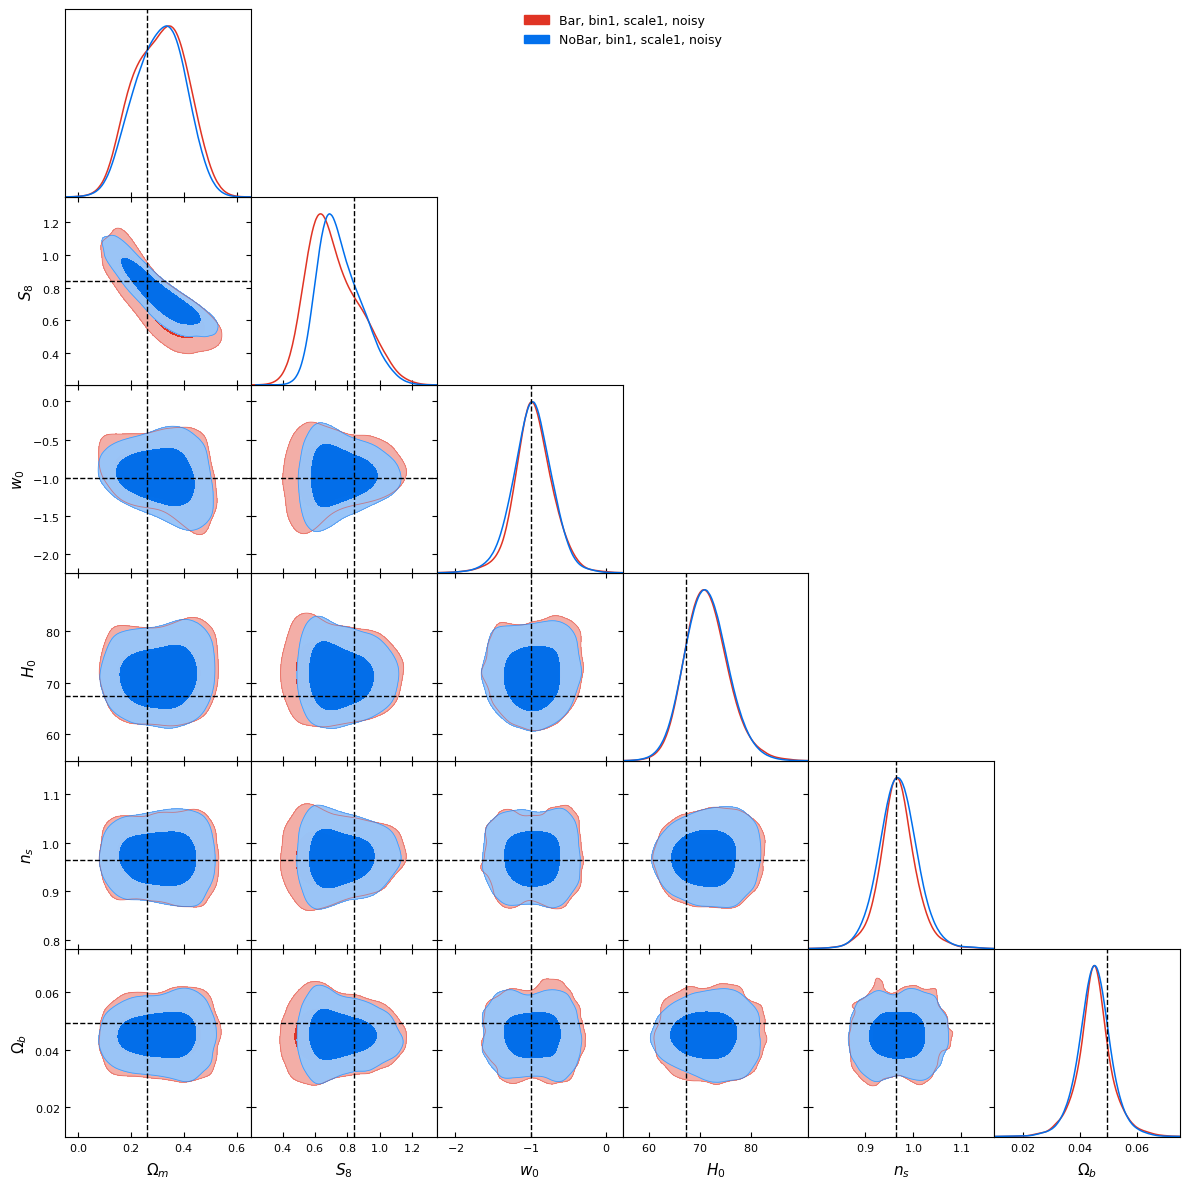

In [248]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_bar, samples_nobar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_Bar_vs_NoBar_bin1_scale1_npe.pdf")
plt.show()

## Scale 2

In [249]:
samples_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin1_noisy_npe.npy", allow_pickle=True)
samples_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_scale2_bin1_noisy_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [250]:
samples_bar = MCSamples(
    samples=samples_bar,
    names=labels,
    label="Bar, bin1, scale2, noisy",
)
samples_nobar = MCSamples(
    samples=samples_nobar,
    names=labels,
    label="NoBar, bin1, scale2, noisy",
)

Removed no burn in
Removed no burn in


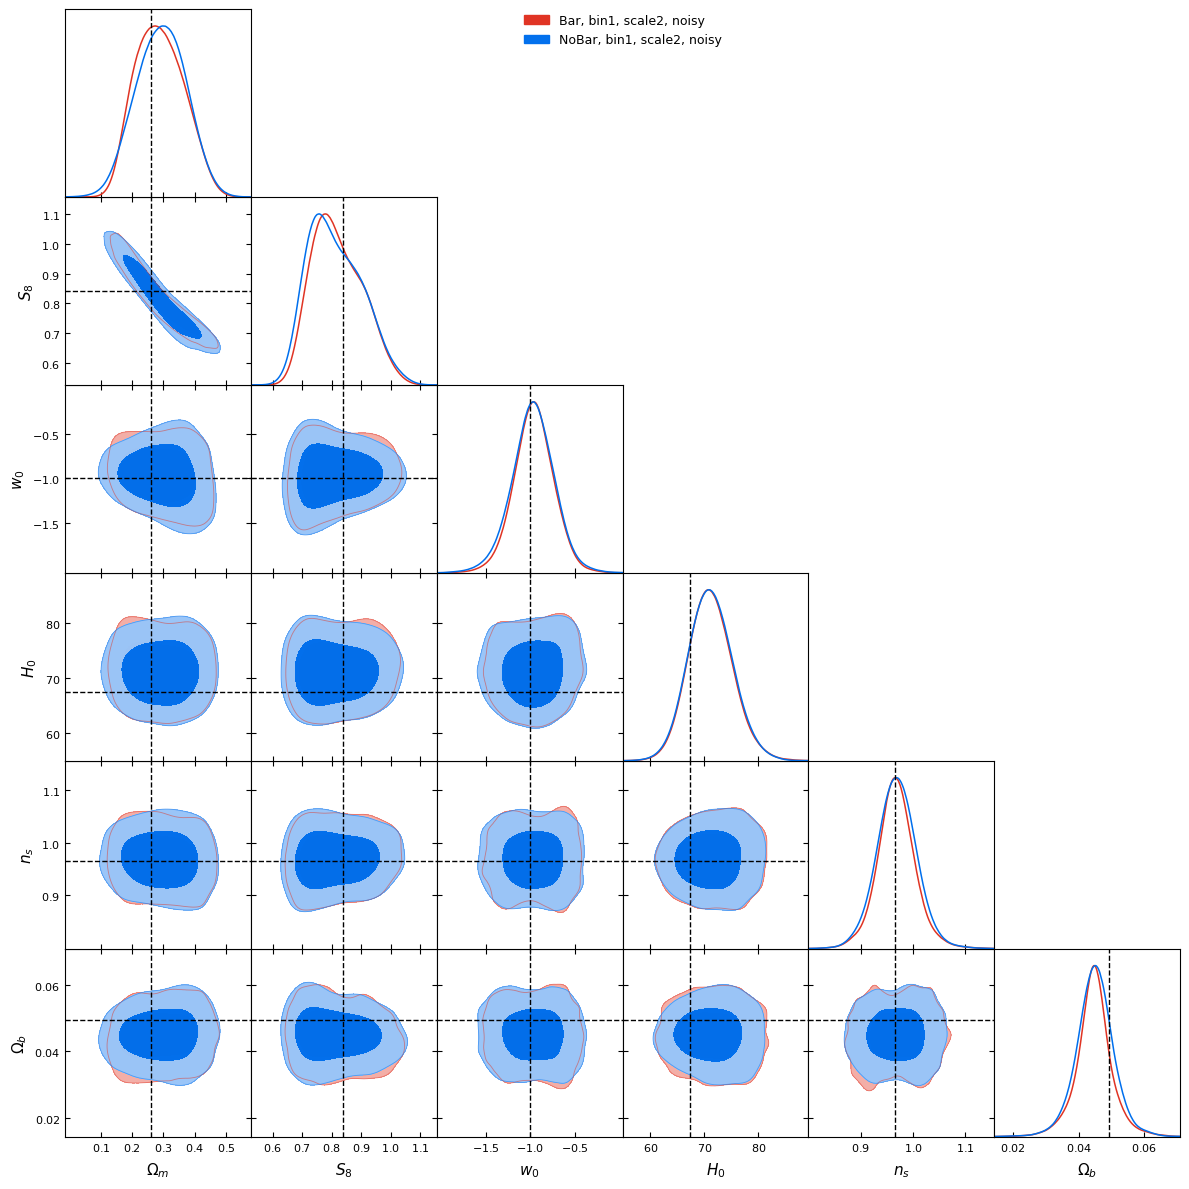

In [251]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_bar, samples_nobar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_Bar_vs_NoBar_bin1_scale2_npe.pdf")
plt.show()

# Get biased contours

## NoBar training data vs Bar fid obs

In [139]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin1_nobaryons_noisy_s026.npy', allow_pickle=True)

In [140]:
params.shape, l1_full.shape

((16965, 6), (16965, 5, 40))

## Scale 1

In [141]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16965, 40)

In [142]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [143]:
dataset = (params, l1_scale1)

In [144]:
inference = NPE()

In [145]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.


[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [146]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale1_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-5,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.


[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -4.506/ Best val loss -5.384:   9%|▉         | 89/1000 [00:44<07:30,  2.02it/s] 

Neural network training stopped after 90 epochs.
Early stopping with best validation metric: -5.383914470672607
Best model saved at epoch 69
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -5.430436611175537
[!] Validation loss: -5.383914470672607
[!] Test loss: -5.7514848709106445


In [147]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [148]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_baryonified_fid_bin1_noisy_s026.npy', allow_pickle=True)

In [149]:
np.array(fid_full).shape

(200, 5, 40)

In [150]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [151]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [152]:
import jax.random as random

master_key = random.PRNGKey(1)

In [153]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [154]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [155]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


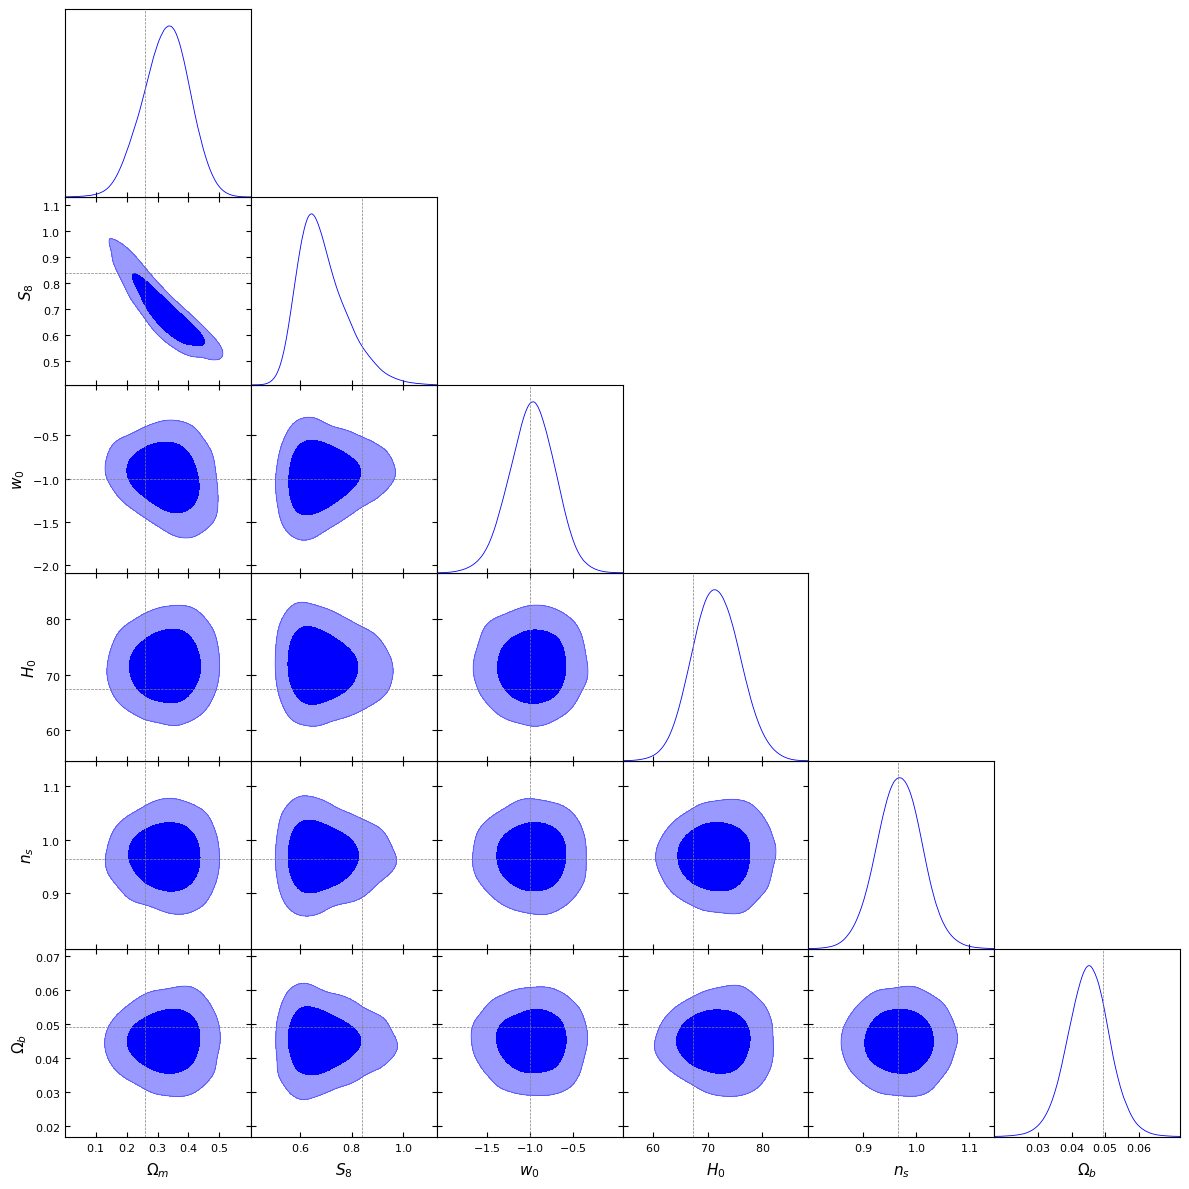

In [156]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="NoBar, bin1, scale1",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [157]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale1_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale1.samples)

In [158]:
samples_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale1_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale1_bin1_noisy_s026_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [159]:
samples_bar = MCSamples(
    samples=samples_bar,
    names=labels,
    label="Bar, bin1, scale1, noisy",
)
samples_nobar = MCSamples(
    samples=samples_nobar,
    names=labels,
    label="NoBar, bin1, scale1, noisy",
)

Removed no burn in
Removed no burn in


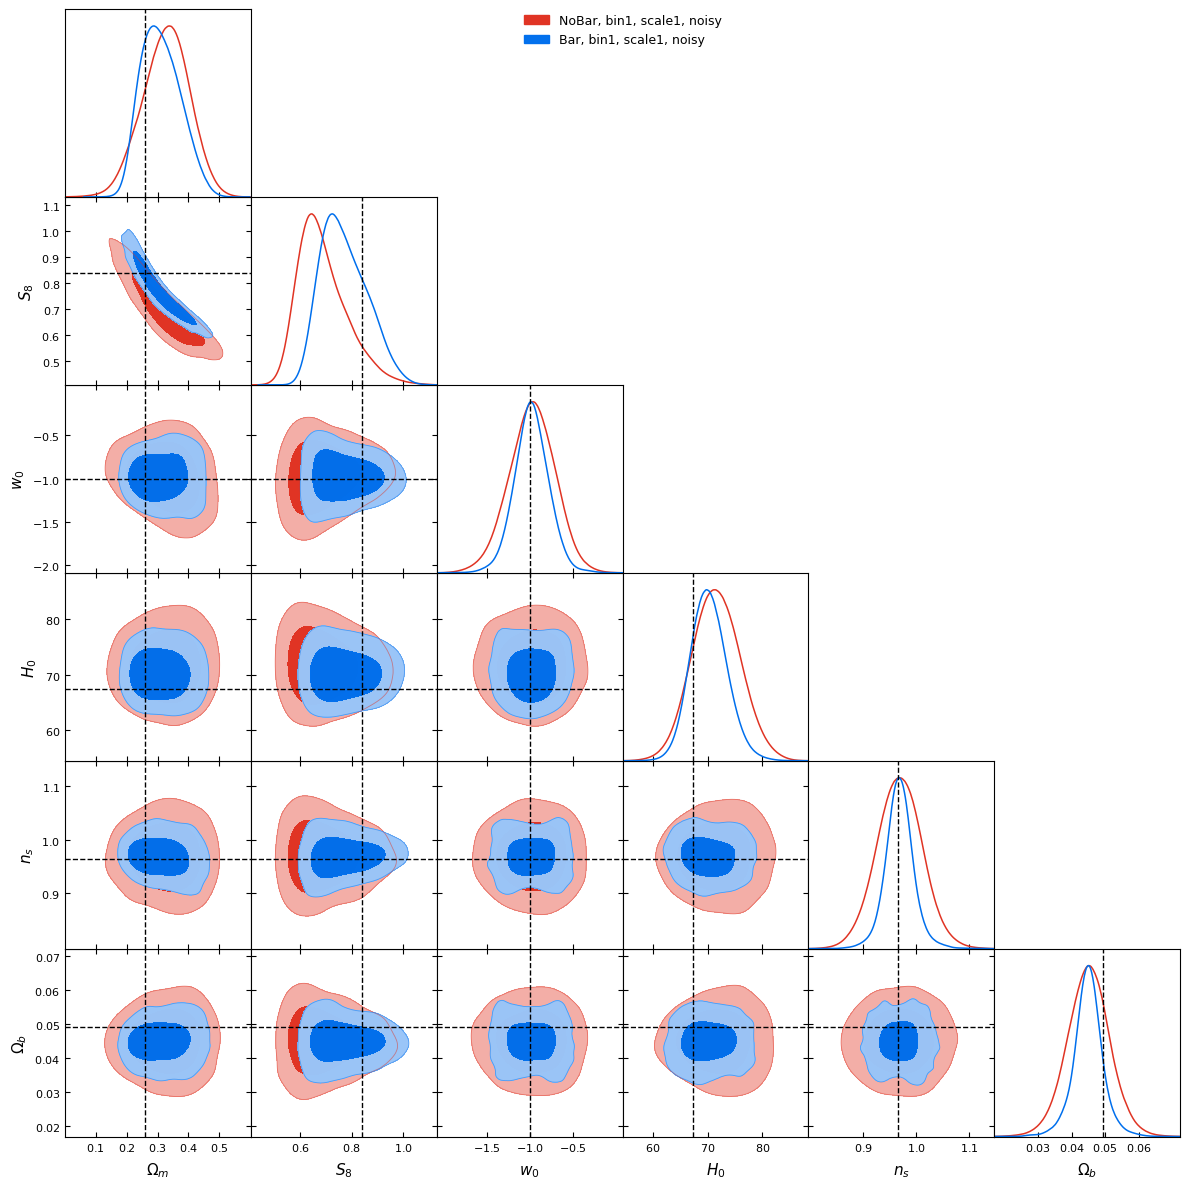

In [162]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_nobar, samples_bar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_vs_NoBar_biased_bin1_scale1_npe.pdf")
plt.show()

## Scale 2

In [163]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16965, 40)

In [164]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)

In [165]:
dataset = (params, l1_scale2)

In [166]:
inference = NPE()

In [167]:
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [168]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale2_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.488/ Best val loss -7.500:  15%|█▍        | 148/1000 [01:03<06:05,  2.33it/s]

Neural network training stopped after 149 epochs.
Early stopping with best validation metric: -7.499804973602295
Best model saved at epoch 146
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.607852935791016
[!] Validation loss: -7.50037145614624
[!] Test loss: -7.542699813842773


In [169]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [170]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_baryonified_fid_bin1_noisy_s026.npy', allow_pickle=True)

In [171]:
np.array(fid_full).shape

(200, 5, 40)

In [172]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [173]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [174]:
import jax.random as random

master_key = random.PRNGKey(1)

In [175]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [176]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [177]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


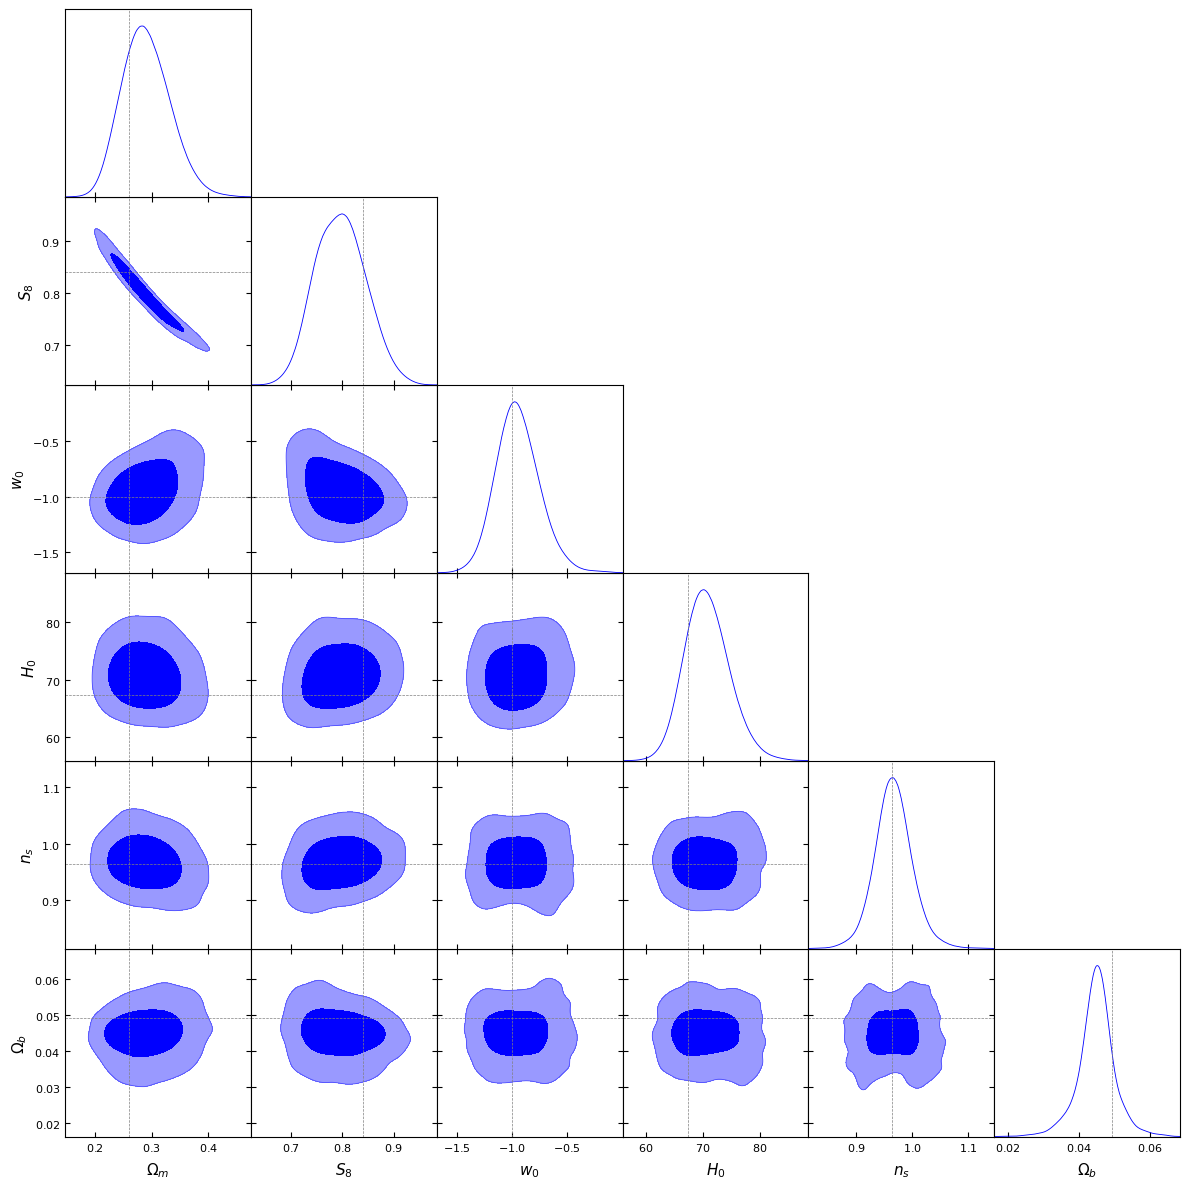

In [178]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale2 = MCSamples(
    samples=samples,
    names=labels,
    label="NoBar, bin1, scale2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [179]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale2_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale2.samples)

In [180]:
samples_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale2_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale2_bin1_noisy_s026_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [181]:
samples_bar = MCSamples(
    samples=samples_bar,
    names=labels,
    label="Bar, bin1, scale2, noisy",
)
samples_nobar = MCSamples(
    samples=samples_nobar,
    names=labels,
    label="NoBar, bin1, scale2, noisy",
)

Removed no burn in
Removed no burn in


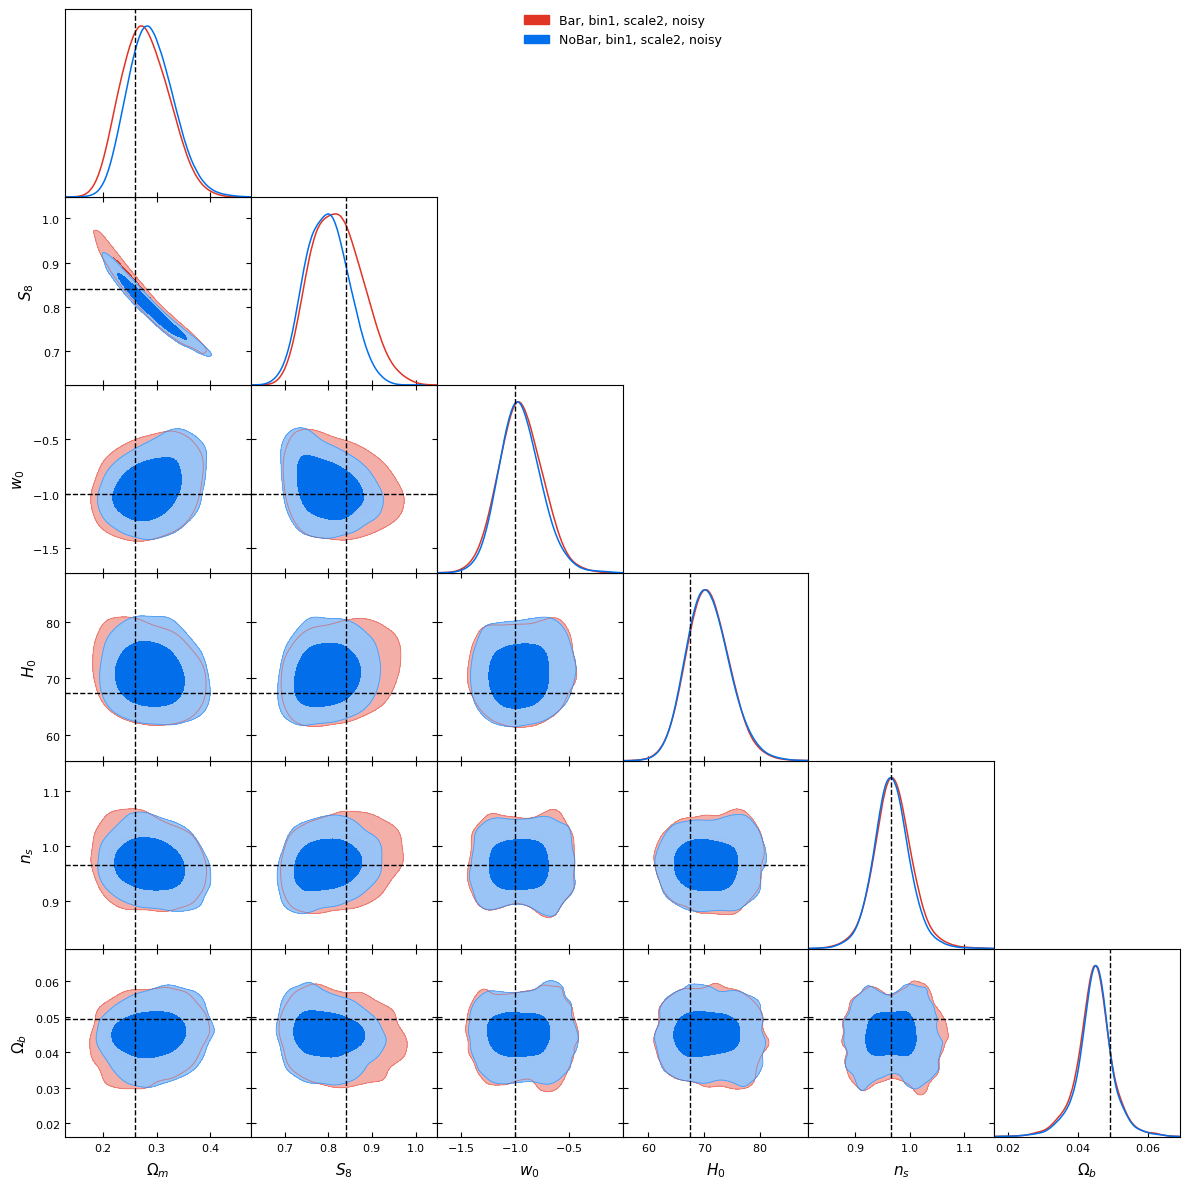

In [183]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_bar, samples_nobar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_vs_NoBar_bin1_scale1_npe.pdf")
plt.show()

## Scale 3

In [184]:
l1_scale3 = l1_full[:, 2]
l1_scale3.shape 

(16965, 40)

In [185]:
params = jnp.array(params)
l1_scale3 = jnp.array(l1_scale3)

In [186]:
dataset = (params, l1_scale3)

In [187]:
inference = NPE()

In [188]:
inference = inference.append_simulations(params, l1_scale3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [189]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_nobaryons_bin1_scale3_noisy"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=1e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -6.950/ Best val loss -6.955:  23%|██▎       | 230/1000 [01:33<05:12,  2.46it/s]

Neural network training stopped after 231 epochs.
Early stopping with best validation metric: -6.954701900482178
Best model saved at epoch 210
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.0758819580078125
[!] Validation loss: -6.954701900482178
[!] Test loss: -7.027115345001221


In [190]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [191]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_baryonified_fid_bin1_noisy_s026.npy', allow_pickle=True)

In [192]:
np.array(fid_full).shape

(200, 5, 40)

In [193]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [194]:
fid_mean_scale3 = fid_mean[2]
fid_mean_scale3.shape

(40,)

Sampling

In [195]:
import jax.random as random

master_key = random.PRNGKey(1)

In [196]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale3, num_samples=num_samples, key=sample_key
)

In [197]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [198]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


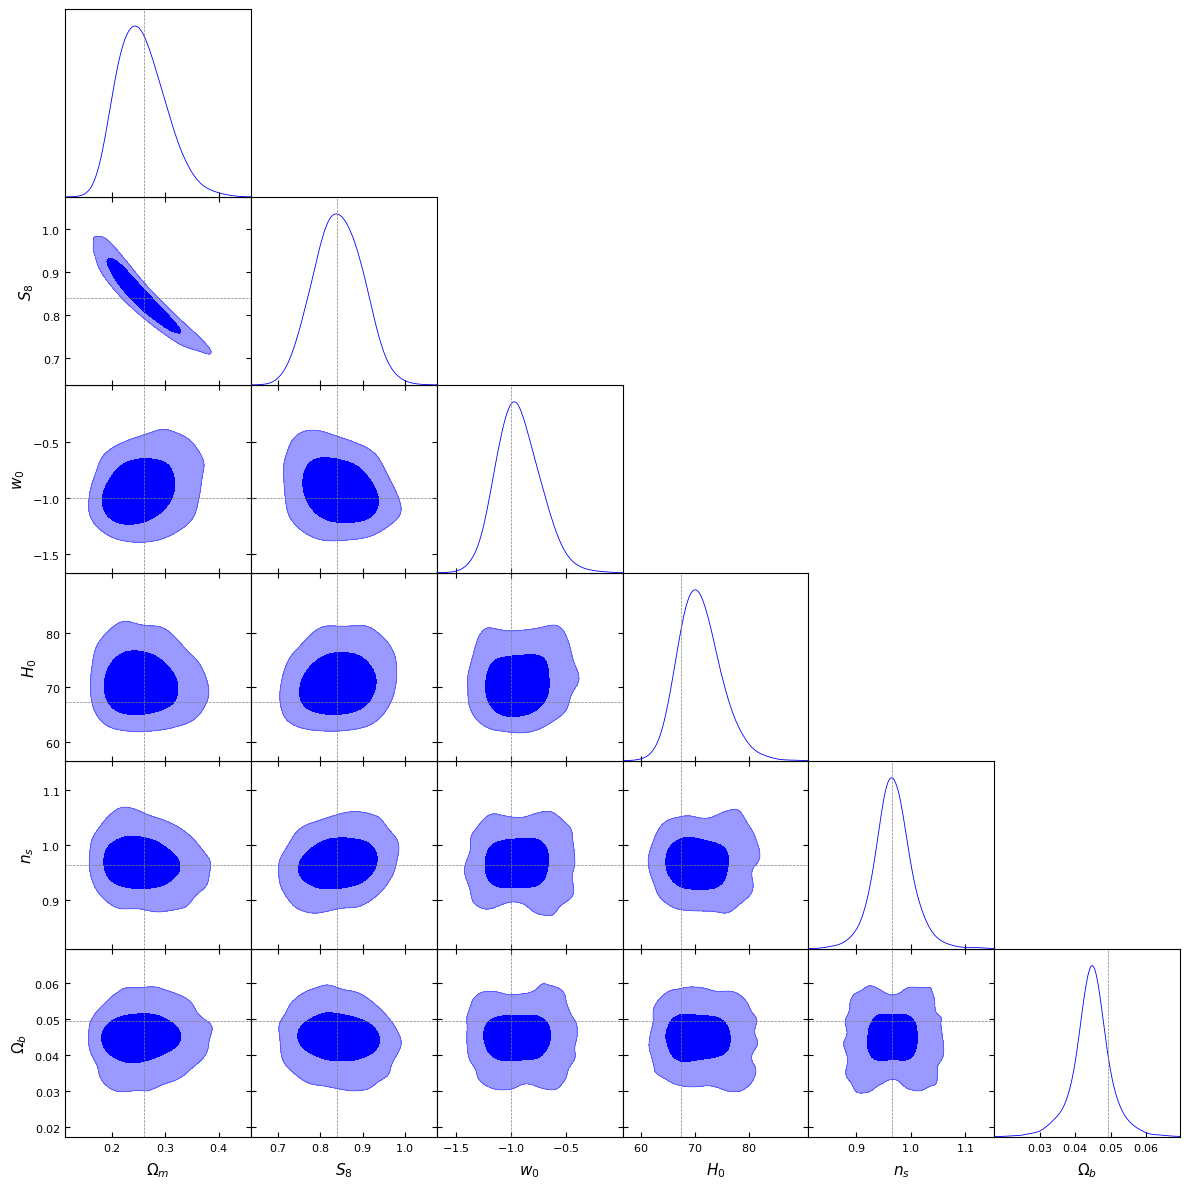

In [199]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_nobar_bin1_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="NoBar, bin1, scale3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_nobar_bin1_scale3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [200]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale3_bin1_noisy_s026_npe.npy", samples_nobar_bin1_scale2.samples)

In [201]:
samples_bar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_bar_scale3_bin1_noisy_s026_npe.npy", allow_pickle=True)
samples_nobar = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_nobar_training_bar_fid_scale3_bin1_noisy_s026_npe.npy", allow_pickle=True)

labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [202]:
samples_bar = MCSamples(
    samples=samples_bar,
    names=labels,
    label="Bar, bin1, scale3, noisy",
)
samples_nobar = MCSamples(
    samples=samples_nobar,
    names=labels,
    label="NoBar, bin1, scale3, noisy",
)

Removed no burn in
Removed no burn in


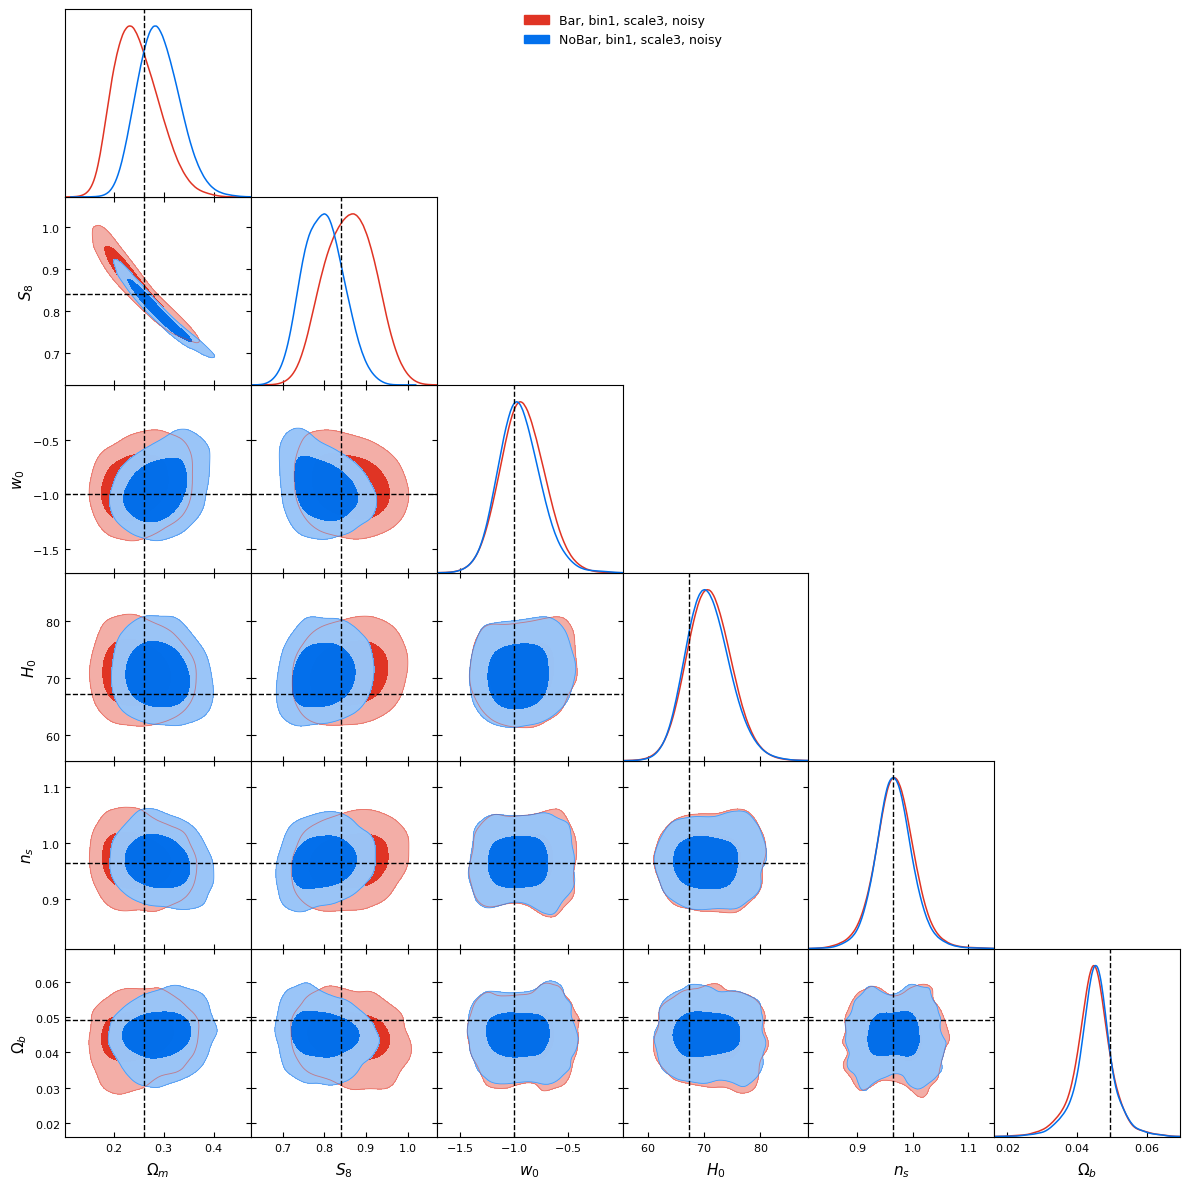

In [203]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_bar, samples_nobar], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/Noisy_s026_Bar_vs_NoBar_bin1_scale3_npe.pdf")
plt.show()